# Wildfire training notebook (LightGBM) — `final`

Train next-day California wildfire risk with **LightGBM** classifier + ranker.

**Flow:** configure → verify data → clean → features → split → pipelines → Optuna → fit → prune/blend → evaluate 2025 → explain → export → diagnostics / sample generation.


## 1. Configuration & environment

**What the next cells do:** check the Python binary, then load libraries, locate the Stage C dataset, set stage/subset/fire-season/neighbor-fire flags, pick CPU/GPU for LightGBM, and create `OUTPUT_DIR`.

**How to read the output:** confirm stage, cell subset, neighbor-fire ON/OFF, fire-season months, and LightGBM device. If GPU was requested but shows CPU, training still runs — just slower.


In [3]:
!which python

/Users/Ripunjay.Kumar/Documents/Hackathon_team_package/.venv/bin/python


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import platform
import subprocess
import tempfile
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "champion-wildfire-mpl"))
os.environ.setdefault("MPLBACKEND", "Agg")

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import sklearn
from sklearn import set_config
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

SEED = 42
# Local layout (cwd): ./stage_c_knn or ./stage_c
# Kaggle Input datasets (lakshay654) remain as fallbacks in candidate_roots():
#   california-wildfire-knn    → stage_c_knn
#   california-wildfire-median → stage_c
#   firms-test/fire_analysis2.csv → CELL_SUBSET high_fire / high_medium_fire
TRAINING_DATA_STAGE = "stage_c_knn"  # change to "stage_c" for median run
TRAINING_DATA_STAGE = os.environ.get("CHAMPION_TRAINING_STAGE", TRAINING_DATA_STAGE).strip()
if TRAINING_DATA_STAGE not in {"stage_c", "stage_c_knn"}:
    raise ValueError("TRAINING_DATA_STAGE must be 'stage_c_knn' or 'stage_c'")
# Default: current directory (expects ./stage_c_knn or ./stage_c). Override with CHAMPION_DATA_DIR.
_STAGE_PATHS = {
    "stage_c_knn": ".",
    "stage_c": ".",
}
DATA_DIRECTORY = os.environ.get("CHAMPION_DATA_DIR", _STAGE_PATHS[TRAINING_DATA_STAGE]).strip()
USE_PRECOMPUTED_KNN = TRAINING_DATA_STAGE == "stage_c_knn"
IMPUTATION_METHOD = "precomputed KNN" if USE_PRECOMPUTED_KNN else "training-only median"

# Fire-region cell subset (orthogonal to stage). Uses fire_analysis2.csv.
CELL_SUBSET = "high_medium_fire"  # all | high_fire | high_medium_fire
CELL_SUBSET = os.environ.get("CHAMPION_CELL_SUBSET", CELL_SUBSET).strip()
if CELL_SUBSET not in {"all", "high_fire", "high_medium_fire"}:
    raise ValueError("CELL_SUBSET must be 'all', 'high_fire', or 'high_medium_fire'")
CELL_SUBSET_CATEGORIES = {
    "all": None,
    "high_fire": ["High Outlier", "High"],
    "high_medium_fire": ["High Outlier", "High", "Medium"],
}
FIRE_REGION_CSV = os.environ.get(
    "CHAMPION_FIRE_REGION_CSV",
    "fire_analysis2.csv",  # local cwd, or attach under /kaggle/input on Kaggle
).strip()  # used when CELL_SUBSET is high_fire / high_medium_fire


# Neighbor / wind-aware fire context (NOT same-cell fire history).
# Set False (or CHAMPION_USE_NEIGHBOR_FIRE=0) to train environmental features only.
USE_NEIGHBOR_FIRE_FEATURES = True
USE_NEIGHBOR_FIRE_FEATURES = os.environ.get(
    "CHAMPION_USE_NEIGHBOR_FIRE",
    "1" if USE_NEIGHBOR_FIRE_FEATURES else "0",
).strip().lower() not in {"0", "false", "no"}


# Fire-season month filter (label_date months). Features are still built on full years
# for causal rolling history; modeling rows are restricted when this is ON.
# Set False (or CHAMPION_FIRE_SEASON_ONLY=0) to use all months.
USE_FIRE_SEASON_ONLY = True
USE_FIRE_SEASON_ONLY = os.environ.get(
    "CHAMPION_FIRE_SEASON_ONLY",
    "1" if USE_FIRE_SEASON_ONLY else "0",
).strip().lower() not in {"0", "false", "no"}
FIRE_SEASON_MONTHS = tuple(
    int(x) for x in os.environ.get("CHAMPION_FIRE_SEASON_MONTHS", "5,6,7,8,9,10,11").split(",")
    if str(x).strip()
)  # default May–November

MODE = os.environ.get("CHAMPION_MODE", "full").strip().lower()
if MODE not in {"full", "smoke"}:
    raise ValueError("CHAMPION_MODE must be 'full' or 'smoke'")
USE_GPU = os.environ.get("CHAMPION_USE_GPU", "1").strip().lower() not in {"0", "false", "no"}
np.random.seed(SEED)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
set_config(display="diagram")

def show(value: Any) -> None:
    try:
        from IPython.display import display
        display(value)
    except ImportError:
        print(value)

def show_image(path: Path) -> None:
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except ImportError:
        print(f"Saved image: {path}")

def candidate_roots() -> list[Path]:
    candidates: list[Path] = []
    configured = DATA_DIRECTORY.strip() or os.environ.get("CHAMPION_DATA_DIR", "").strip()
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    # Prefer local checkout: cwd and parent dirs (./stage_c_knn), then Kaggle Inputs.
    candidates.append(current)
    candidates.extend(base / TRAINING_DATA_STAGE for base in (current, *current.parents))
    candidates.extend([
        Path("/kaggle/input/datasets/lakshay654/california-wildfire-knn"),
        Path("/kaggle/input/datasets/lakshay654/california-wildfire-median"),
        Path("/kaggle/input/datasets/roushanks/dsai-datasets"),
        Path("/kaggle/input/dsai-datasets"),
    ])
    if Path("/kaggle/input").is_dir():
        candidates.extend(path.parent for path in Path("/kaggle/input").rglob("dataset_metadata.json"))
    candidates.extend(base / "Archive" for base in (current, *current.parents))
    return list(dict.fromkeys(path.resolve() for path in candidates))

def read_metadata_stage(path: Path) -> str | None:
    try:
        return json.loads(path.read_text(encoding="utf-8")).get("stage")
    except (OSError, json.JSONDecodeError):
        return None

def locate_data(expected_stage: str) -> dict[str, Path | str]:
    checked: list[str] = []
    for root in candidate_roots():
        stage_folder = "stage_c_knn" if expected_stage == "stage_c_knn" else "stage_c"
        layouts = [
            {
                "layout": "flat four-file", "root": root,
                "all": root / "all.parquet", "meta": root / "meta.json",
                "dataset_metadata": root / "dataset_metadata.json", "features": root / "feature_columns.json",
            },
            {
                "layout": "extracted local", "root": root / stage_folder,
                "all": root / stage_folder / "all.parquet", "meta": root / stage_folder / "meta.json",
                "dataset_metadata": root / stage_folder / "metadata" / "dataset_metadata.json",
                "features": root / stage_folder / "metadata" / "feature_columns.json",
            },
            {
                "layout": "legacy Stage C", "root": root,
                "all": root / "stage_c" / "all.parquet", "meta": root / "meta.json",
                "dataset_metadata": root / "stage_c" / "metadata" / "dataset_metadata.json",
                "features": root / "stage_c" / "metadata" / "feature_columns.json",
            },
        ]
        for layout in layouts:
            ready = all(Path(layout[key]).is_file() for key in ("all", "meta", "dataset_metadata", "features"))
            stage = read_metadata_stage(Path(layout["dataset_metadata"])) if ready else None
            checked.append(f"{layout['layout']}: {layout['root']} (stage={stage})")
            if ready and stage == expected_stage:
                return layout
    raise FileNotFoundError(
        f"Could not find a four-file dataset with stage={expected_stage}. Set DATA_DIRECTORY. Checked:\n"
        + "\n".join(f"  - {item}" for item in checked)
    )

DATA = locate_data(TRAINING_DATA_STAGE)
DATA_ROOT = Path(DATA["root"])
ALL_PARQUET = Path(DATA["all"])
META_JSON = Path(DATA["meta"])
DATASET_METADATA_JSON = Path(DATA["dataset_metadata"])
FEATURE_COLUMNS_JSON = Path(DATA["features"])
default_output = (
    Path(f"/kaggle/working/champion_training_outputs_{TRAINING_DATA_STAGE}_{CELL_SUBSET}")
    if Path("/kaggle/working").is_dir()
    else Path.cwd() / "notebook_outputs" / f"champion_training_{TRAINING_DATA_STAGE}_{CELL_SUBSET}_{MODE}"
)
OUTPUT_DIR = Path(os.environ.get("CHAMPION_OUTPUT_DIR", str(default_output))).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def reported_gpu() -> str | None:
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True, capture_output=True, text=True, timeout=10,
        )
        values = [line.strip() for line in result.stdout.splitlines() if line.strip()]
        return ", ".join(values) if values else None
    except (FileNotFoundError, subprocess.SubprocessError):
        return None

def lightgbm_device() -> tuple[str, dict[str, str]]:
    if not USE_GPU:
        return "cpu", {"cpu": "GPU disabled"}
    rng = np.random.default_rng(SEED)
    x = rng.normal(size=(2000, 20)).astype("float32")
    y = rng.integers(0, 2, size=2000, dtype="int8")
    failures: dict[str, str] = {}
    for device in ("cuda", "gpu"):
        try:
            dataset = lgb.Dataset(x, label=y)
            lgb.train(
                {"objective": "binary", "device_type": device, "verbosity": -1, "seed": SEED},
                dataset, num_boost_round=2,
            )
            return device, failures
        except Exception as error:
            failures[device] = str(error).splitlines()[-1][:400]
    return "cpu", failures

DEVICE, DEVICE_FAILURES = lightgbm_device()
GPU_NAME = reported_gpu()

print("=" * 72)
print("CHAMPION TRAINING CONFIGURATION")
print("=" * 72)
print(f"Training stage:    {TRAINING_DATA_STAGE}")
print(f"Cell subset:       {CELL_SUBSET}")
print(f"Imputation:        {IMPUTATION_METHOD}")
print(f"Neighbor fire feats: {'ON' if USE_NEIGHBOR_FIRE_FEATURES else 'OFF'}")
print(
    f"Fire season only:  {'ON' if USE_FIRE_SEASON_ONLY else 'OFF'}"
    + (f" months={FIRE_SEASON_MONTHS}" if USE_FIRE_SEASON_ONLY else "")
)
print(f"Mode:              {MODE}")
print(f"Input layout:      {DATA['layout']}")
print(f"Input directory:   {DATA_ROOT}")
print(f"Output directory:  {OUTPUT_DIR}")
print(f"Reported GPU:      {GPU_NAME or 'not reported'}")
print(f"LightGBM device:   {DEVICE}")
if USE_GPU and DEVICE == "cpu":
    print("GPU requested but unavailable to this LightGBM build; using CPU safely.")
    for name, message in DEVICE_FAILURES.items():
        print(f"  {name}: {message}")
print("=" * 72)


CHAMPION TRAINING CONFIGURATION
Training stage:    stage_c_knn
Cell subset:       high_medium_fire
Imputation:        precomputed KNN
Neighbor fire feats: ON
Fire season only:  ON months=(5, 6, 7, 8, 9, 10, 11)
Mode:              full
Input layout:      extracted local
Input directory:   /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/stage_c_knn
Output directory:  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full
Reported GPU:      not reported
LightGBM device:   cpu
GPU requested but unavailable to this LightGBM build; using CPU safely.
  cuda: Please recompile with CMake option -DUSE_CUDA=1
  gpu: Please recompile with CMake option -DUSE_GPU=1


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1


## 2. Verify dataset quantity

**What the next cell does:** read metadata, count rows/cells/days/fires by year, and save a quantity bar chart.




In [5]:
def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))

archive_meta = read_json(META_JSON)
dataset_meta = read_json(DATASET_METADATA_JSON)
raw_features = read_json(FEATURE_COLUMNS_JSON)
parquet_file = pq.ParquetFile(ALL_PARQUET)
schema_columns = set(parquet_file.schema_arrow.names)
if dataset_meta.get("stage") != TRAINING_DATA_STAGE:
    raise ValueError("The selected metadata stage changed after discovery")
if dataset_meta.get("s5p_2021_mode") != "ready":
    raise ValueError("The data2.0 table must report S5P 2021 as ready")

missing_flag_column = None
if USE_PRECOMPUTED_KNN:
    missing_flag_column = "s2n_knn_imputed"
    if missing_flag_column not in schema_columns:
        raise ValueError("stage_c_knn must contain s2n_knn_imputed")
    knn_metadata = dataset_meta.get("knn", {})
    if (
        knn_metadata.get("n_neighbors") != 5
        or knn_metadata.get("weights") != "distance"
        or knn_metadata.get("donor_pool") != "train_years_<=_2022_and_s2n_available_eq_1"
    ):
        raise ValueError("The KNN metadata does not match the verified train-only data2.0 contract")

model_source_features = list(dict.fromkeys([
    *raw_features,
    *([missing_flag_column] if missing_flag_column else []),
]))
coverage_probe = pd.read_parquet(ALL_PARQUET, columns=["cell_id", "label_date", "y_fire"])
SOURCE_ROWS = int(len(coverage_probe))
SOURCE_CELLS = int(coverage_probe["cell_id"].nunique())
SOURCE_DAYS = int(pd.to_datetime(coverage_probe["label_date"]).nunique())
SOURCE_POSITIVES = int(coverage_probe["y_fire"].sum())
SOURCE_POSITIVE_RATE = SOURCE_POSITIVES / SOURCE_ROWS
del coverage_probe
gc.collect()
if SOURCE_ROWS != int(dataset_meta["n_rows"]) or SOURCE_POSITIVES != int(dataset_meta["n_pos"]):
    raise ValueError("Parquet coverage does not match dataset_metadata.json")

ID_COLUMNS = [
    "feature_end_date", "eo_asof_date", "label_date", "cell_id",
    "latitude", "longitude", "y_fire",
]
AGE_COLUMNS = ["s2n_lag_days", "s5n_lag_days"]
required_columns = set(ID_COLUMNS + AGE_COLUMNS + model_source_features)
missing_columns = sorted(required_columns - schema_columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

input_files = [ALL_PARQUET, META_JSON, DATASET_METADATA_JSON, FEATURE_COLUMNS_JSON]
show(pd.DataFrame([
    {
        "file": path.name,
        "format": path.suffix.lstrip(".").upper(),
        "size_mb": path.stat().st_size / 1024**2,
        "purpose": (
            "complete cell-by-day table" if path == ALL_PARQUET
            else "compact archive metadata" if path == META_JSON
            else "stage, split, and preprocessing metadata" if path == DATASET_METADATA_JSON
            else "exact Stage C feature allowlist"
        ),
    }
    for path in input_files
]).round({"size_mb": 3}))

quantity_overview = pd.DataFrame([
    {"measure": "Rows", "quantity": SOURCE_ROWS},
    {"measure": "Columns on disk", "quantity": len(parquet_file.schema_arrow.names)},
    {"measure": "Stage C allowlisted features", "quantity": len(raw_features)},
    {"measure": "Additional KNN flag features", "quantity": int(USE_PRECOMPUTED_KNN)},
    {"measure": "Calendar days", "quantity": SOURCE_DAYS},
    {"measure": "California grid cells", "quantity": SOURCE_CELLS},
    {"measure": "Positive cell-days", "quantity": SOURCE_POSITIVES},
    {"measure": "Positive rate", "quantity": SOURCE_POSITIVE_RATE},
])
show(quantity_overview)
if USE_PRECOMPUTED_KNN:
    print(f"Verified KNN donor pool: {dataset_meta['knn']['donor_pool']}")
print(f"Verified coverage: {SOURCE_CELLS:,} cells × {SOURCE_DAYS:,} days = {SOURCE_ROWS:,} rows")

,file,format,size_mb,purpose
0,all.parquet,PARQUET,322.096,complete cell-by-day table
1,meta.json,JSON,0.000,compact archive metadata
2,dataset_metadata.json,JSON,0.003,"stage, split, and preprocessing metadata"
3,feature_columns.json,JSON,0.001,exact Stage C feature allowlist


,measure,quantity
0,Rows,1.718304e+06
1,Columns on disk,7.700000e+01
2,Stage C allowlisted features,6.300000e+01
3,Additional KNN flag features,1.000000e+00
4,Calendar days,2.557000e+03
5,California grid cells,6.720000e+02
6,Positive cell-days,2.161500e+04
7,Positive rate,1.257926e-02


Verified KNN donor pool: train_years_<=_2022_and_s2n_available_eq_1
Verified coverage: 672 cells × 2,557 days = 1,718,304 rows


## 3. Load & preprocess source table

**What the next cell does:** load `all.parquet`, drop constant columns, apply KNN/median contract, optionally restrict to fire-region cells (`CELL_SUBSET`).


fire_analysis2.csv category counts: {'Medium': 293, 'Low': 140, 'High': 115, 'High Outlier': 31}
CELL_SUBSET=high_medium_fire: categories=['High Outlier', 'High', 'Medium'] selected_cells=437 csv_only_not_in_stage_c=2
Loaded subset: cells=437 days=2,557 rows=1,117,409 positives=21,069 CELL_SUBSET=high_medium_fire


,rows,positives,days,positive_rate
year,,,,
2019,159505,2308,365,1.447%
2020,159942,4692,366,2.934%
2021,159505,4115,365,2.580%
2022,159505,2392,365,1.500%
2023,159505,2934,365,1.839%
2024,159942,2426,366,1.517%
2025,159505,2202,365,1.381%


{
  "knn_imputed_rows_flagged": 2185,
  "swvl1_mean_negative_rows_clipped": 3108,
  "swvl2_mean_negative_rows_clipped": 4398,
  "soil_moisture_index_negative_rows_clipped": 1066,
  "swvl1_mean_7d_negative_rows_clipped": 2250
}
Loaded 1,117,409 rows in 2.0s


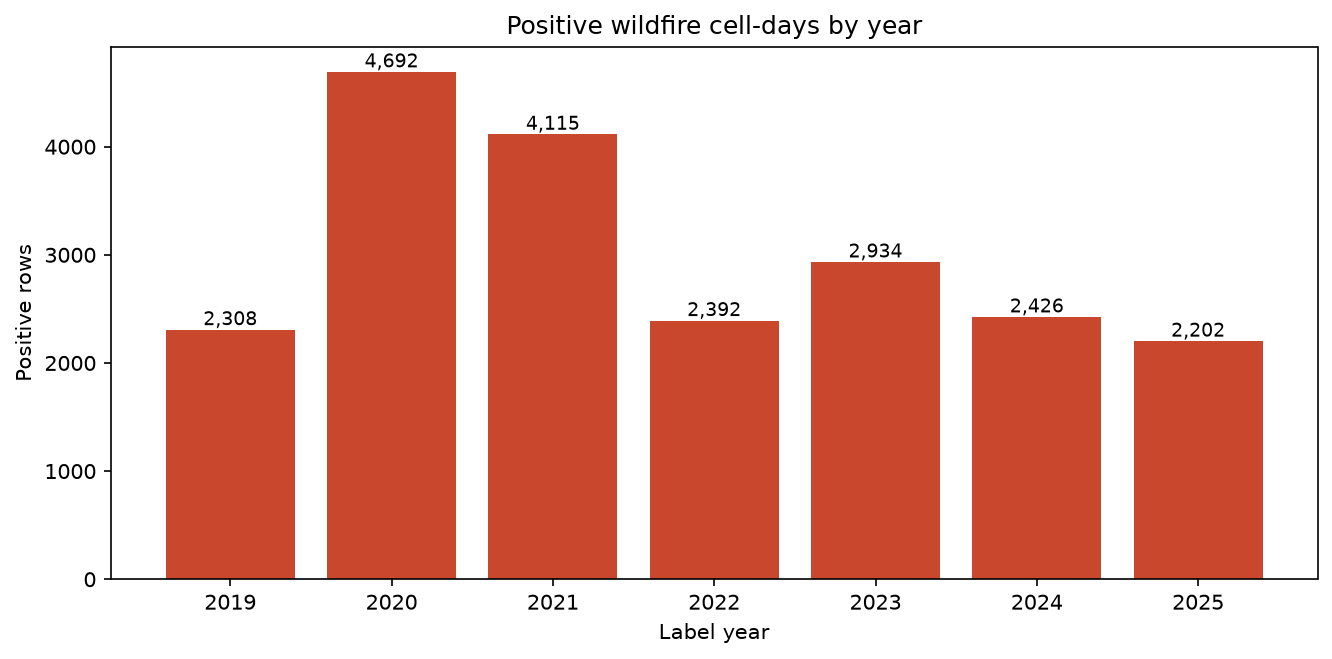

In [141]:
CONSTANT_FEATURES = {"s5n_s5p_aai_std", "s5n_s5p_co_std"}
base_features = [name for name in model_source_features if name not in CONSTANT_FEATURES]
load_columns = list(dict.fromkeys([*ID_COLUMNS, *AGE_COLUMNS, *model_source_features]))

def clean_source_table(frame: pd.DataFrame, raw_base_features: list[str]):
    """Apply only the preprocessing appropriate to the selected source stage."""
    frame = frame.copy()
    for name in ("feature_end_date", "eo_asof_date", "label_date"):
        frame[name] = pd.to_datetime(frame[name]).dt.normalize()
    frame = frame.sort_values(["cell_id", "label_date"]).reset_index(drop=True)
    cleanup_counts: dict[str, int] = {}

    if USE_PRECOMPUTED_KNN:
        frame[raw_base_features] = frame[raw_base_features].apply(pd.to_numeric, errors="raise").astype("float32")
        flag_values = set(frame[missing_flag_column].dropna().unique().tolist())
        if not flag_values.issubset({0.0, 1.0}):
            raise ValueError(f"{missing_flag_column} must be binary; found {sorted(flag_values)}")
        if not np.isfinite(frame[raw_base_features].to_numpy(dtype="float32", copy=False)).all():
            raise ValueError("Precomputed KNN values contain NaN or infinity")
        flagged = frame[missing_flag_column].eq(1)
        if not frame.loc[flagged, "s2n_available"].eq(0).all():
            raise ValueError("Every KNN-imputed S2 row must retain s2n_available=0")
        cleanup_counts["knn_imputed_rows_flagged"] = int(flagged.sum())
    else:
        s2_invalid = frame["s2n_available"].ne(1)
        s2_values = [name for name in raw_base_features if name.startswith("s2n_") and name != "s2n_available"]
        frame.loc[s2_invalid, s2_values] = np.nan
        frame.loc[s2_invalid, "s2n_available"] = 0.0
        cleanup_counts["sentinel2_rows_marked_missing"] = int(s2_invalid.sum())
        s5_invalid = frame["s5n_available"].ne(1)
        s5_values = [name for name in raw_base_features if name.startswith("s5n_") and name != "s5n_available"]
        frame.loc[s5_invalid, s5_values] = 0.0
        frame.loc[s5_invalid, "s5n_available"] = 0.0
        cleanup_counts["sentinel5p_rows_zeroed"] = int(s5_invalid.sum())
        frame[raw_base_features] = frame[raw_base_features].astype("float32")

    for name in ("swvl1_mean", "swvl2_mean", "soil_moisture_index", "swvl1_mean_7d"):
        cleanup_counts[f"{name}_negative_rows_clipped"] = int(frame[name].lt(0).sum())
        frame[name] = frame[name].clip(lower=0)
    frame["year"] = frame["label_date"].dt.year.astype("int16")
    return frame, cleanup_counts

started = time.time()
def resolve_fire_region_csv() -> Path:
    configured = (FIRE_REGION_CSV or "").strip()
    candidates: list[Path] = []
    if configured:
        candidates.append(Path(configured).expanduser())
    candidates.append(Path("/kaggle/input/datasets/lakshay654/firms-test/fire_analysis2.csv"))
    candidates.append(Path.cwd() / "fire_analysis2.csv")
    # Notebook / Milestone 5 directory heuristics
    here = Path.cwd().resolve()
    candidates.extend([
        here / "Milestone 5" / "fire_analysis2.csv",
        here.parent / "Milestone 5" / "fire_analysis2.csv",
    ])
    for base in (here, *here.parents):
        candidates.append(base / "fire_analysis2.csv")
        candidates.append(base / "Milestone 5" / "fire_analysis2.csv")
    if Path("/kaggle/input").is_dir():
        candidates.extend(Path("/kaggle/input").rglob("fire_analysis2.csv"))
    seen: set[Path] = set()
    for path in candidates:
        path = path.resolve()
        if path in seen:
            continue
        seen.add(path)
        if path.is_file():
            return path
    raise FileNotFoundError(
        "fire_analysis2.csv not found for CELL_SUBSET="
        f"{CELL_SUBSET}. Set FIRE_REGION_CSV or attach the CSV under /kaggle/input."
    )


def cells_for_subset(csv_path: Path, categories: list[str], available_cells: list) -> list:
    frame = pd.read_csv(csv_path)
    required = {"cell_id", "fire_region_category"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"fire_analysis2.csv missing columns: {sorted(missing)}")
    frame["cell_id"] = frame["cell_id"].astype(str)
    available = {str(cell) for cell in available_cells}
    counts = frame["fire_region_category"].value_counts(dropna=False).to_dict()
    print("fire_analysis2.csv category counts:", counts)
    allow = set(
        frame.loc[frame["fire_region_category"].isin(categories), "cell_id"].astype(str)
    )
    selected = [cell for cell in available_cells if str(cell) in allow]
    if not selected:
        raise ValueError(
            f"No Stage C cells matched CELL_SUBSET={CELL_SUBSET} categories={categories}"
        )
    unmatched_csv = sorted(allow - available)
    print(
        f"CELL_SUBSET={CELL_SUBSET}: categories={categories} "
        f"selected_cells={len(selected)} "
        f"csv_only_not_in_stage_c={len(unmatched_csv)}"
    )
    return selected


cell_table = pd.read_parquet(ALL_PARQUET, columns=["cell_id"])
archive_cells = sorted(cell_table["cell_id"].unique().tolist())
selected_cells = list(archive_cells)
FIRE_REGION_CSV_PATH = None
if MODE == "smoke":
    positions = np.linspace(0, len(selected_cells) - 1, min(96, len(selected_cells)), dtype=int)
    selected_cells = list(dict.fromkeys(selected_cells[position] for position in positions))
if CELL_SUBSET != "all":
    FIRE_REGION_CSV_PATH = resolve_fire_region_csv()
    selected_cells = cells_for_subset(
        FIRE_REGION_CSV_PATH,
        CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        selected_cells,
    )
del cell_table
gc.collect()

SELECTED_TRAINING_CELLS = list(selected_cells)
CELL_SUBSET_INFO = {
    "cell_subset": CELL_SUBSET,
    "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
    "n_cells_selected": len(SELECTED_TRAINING_CELLS),
    "n_archive_cells": len(archive_cells),
    "fire_region_csv": str(FIRE_REGION_CSV_PATH) if FIRE_REGION_CSV_PATH else None,
}

if len(SELECTED_TRAINING_CELLS) == len(archive_cells) and CELL_SUBSET == "all" and MODE != "smoke":
    data = pd.read_parquet(ALL_PARQUET, columns=load_columns)
else:
    data = pd.read_parquet(
        ALL_PARQUET,
        columns=load_columns,
        filters=[("cell_id", "in", SELECTED_TRAINING_CELLS)],
    )

data, cleanup = clean_source_table(data, base_features)
cells = int(data["cell_id"].nunique())
days = int(data["label_date"].nunique())
assert len(data) == cells * days
assert data.duplicated(["cell_id", "label_date"]).sum() == 0
assert sorted(data["y_fire"].unique().tolist()) == [0, 1]
assert (data["label_date"] - data["eo_asof_date"]).dt.days.eq(1).all()
assert (data["eo_asof_date"] - data["feature_end_date"]).dt.days.eq(5).all()
if cells != len(SELECTED_TRAINING_CELLS):
    raise ValueError(
        f"Loaded cells ({cells}) do not match selected subset ({len(SELECTED_TRAINING_CELLS)})"
    )
print(
    f"Loaded subset: cells={cells:,} days={days:,} rows={len(data):,} "
    f"positives={int(data['y_fire'].sum()):,} CELL_SUBSET={CELL_SUBSET}"
)
if USE_PRECOMPUTED_KNN and MODE == "full" and CELL_SUBSET == "all":
    if cleanup["knn_imputed_rows_flagged"] != int(dataset_meta["n_s2_knn_imputed"]):
        raise ValueError("Full KNN flag count does not match metadata")

yearly_quantity = data.groupby("year").agg(
    rows=("y_fire", "size"), positives=("y_fire", "sum"), days=("label_date", "nunique"),
)
yearly_quantity["positive_rate"] = yearly_quantity["positives"] / yearly_quantity["rows"]
yearly_quantity_display = yearly_quantity.copy()
yearly_quantity_display["positive_rate"] = yearly_quantity_display["positive_rate"].map(lambda value: f"{value:.3%}")
show(yearly_quantity_display)
print(json.dumps(cleanup, indent=2))
print(f"Loaded {len(data):,} rows in {time.time() - started:.1f}s")

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
figure, axis = plt.subplots(figsize=(9, 4.5))
axis.bar(yearly_quantity.index.astype(str), yearly_quantity["positives"], color="#c9472c")
axis.set(title="Positive wildfire cell-days by year", xlabel="Label year", ylabel="Positive rows")
for position, value in enumerate(yearly_quantity["positives"]):
    axis.text(position, value, f"{int(value):,}", ha="center", va="bottom", fontsize=9)
figure.tight_layout()
quantity_plot = plots_dir / "data_quantity_by_year.png"
figure.savefig(quantity_plot, dpi=150, bbox_inches="tight")
plt.close(figure)
show_image(quantity_plot)


## 4. Feature engineering

**What the next cells do:** define rolling/weather/calendar/ignition features (and optional neighbor-fire features), then build the model table and optionally keep fire-season months only.



In [142]:
def rolling_matrix(values: np.ndarray, window: int, operation: str) -> np.ndarray:
    rolling = pd.DataFrame(values.T).rolling(window=window, min_periods=1)
    return getattr(rolling, operation)().to_numpy(dtype="float32").T

def simple_neighbors(frame: pd.DataFrame, cells: int, days: int) -> list[np.ndarray]:
    coordinates = frame.iloc[np.arange(cells) * days][["latitude", "longitude"]].to_numpy(dtype="float64")
    result = []
    for latitude, longitude in coordinates:
        delta_lat = np.abs(coordinates[:, 0] - latitude)
        delta_lon = np.abs(coordinates[:, 1] - longitude)
        mask = (
            (delta_lat <= 0.251)
            & (delta_lon <= 0.251)
            & ~((delta_lat < 1e-9) & (delta_lon < 1e-9))
        )
        result.append(np.flatnonzero(mask))
    return result

def sum_neighbors(values: np.ndarray, neighbors: list[np.ndarray]) -> np.ndarray:
    output = np.zeros_like(values, dtype="float32")
    for index, adjacent in enumerate(neighbors):
        if adjacent.size:
            output[index] = values[adjacent].sum(axis=0)
    return output

def directional_geometry(coordinates: np.ndarray):
    result = []
    for latitude, longitude in coordinates:
        delta_lat = latitude - coordinates[:, 0]
        delta_lon = (longitude - coordinates[:, 1]) * np.cos(np.deg2rad(latitude))
        distance = np.sqrt(delta_lat**2 + delta_lon**2)
        adjacent = np.flatnonzero((distance > 1e-9) & (distance <= 0.36))
        result.append((
            adjacent,
            (delta_lon[adjacent] / distance[adjacent]).astype("float32"),
            (delta_lat[adjacent] / distance[adjacent]).astype("float32"),
            (1.0 / (distance[adjacent] + 0.05)).astype("float32"),
        ))
    return result

def directional_counts(fire: np.ndarray, wind_sin: np.ndarray, wind_cos: np.ndarray, geometry):
    cells, days = fire.shape
    upwind = np.zeros((cells, days), dtype="float32")
    downwind = np.zeros((cells, days), dtype="float32")
    crosswind = np.zeros((cells, days), dtype="float32")
    distance_weighted = np.zeros((cells, days), dtype="float32")
    wind_east, wind_north = -wind_sin, -wind_cos
    for index, (adjacent, east, north, inverse_distance) in enumerate(geometry):
        if not adjacent.size:
            continue
        neighbor_fire = fire[adjacent]
        alignment = wind_east[index][None, :] * east[:, None] + wind_north[index][None, :] * north[:, None]
        upwind[index] = (neighbor_fire * np.maximum(alignment, 0) * inverse_distance[:, None]).sum(axis=0)
        downwind[index] = (neighbor_fire * np.maximum(-alignment, 0) * inverse_distance[:, None]).sum(axis=0)
        crosswind[index] = (
            neighbor_fire * np.sqrt(np.maximum(1.0 - alignment**2, 0)) * inverse_distance[:, None]
        ).sum(axis=0)
        distance_weighted[index] = (neighbor_fire * inverse_distance[:, None]).sum(axis=0)
    return upwind, downwind, crosswind, distance_weighted

def build_features(frame: pd.DataFrame, raw_base_features: list[str]):
    cells = int(frame["cell_id"].nunique())
    days = int(frame["label_date"].nunique())

    # Calendar cycles.
    day_of_year = frame["eo_asof_date"].dt.dayofyear.to_numpy(dtype="float32")
    month = frame["eo_asof_date"].dt.month.to_numpy(dtype="float32")
    calendar = pd.DataFrame({
        "day_of_year_sin": np.sin(2 * np.pi * day_of_year / 365.25),
        "day_of_year_cos": np.cos(2 * np.pi * day_of_year / 365.25),
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
    }, index=frame.index).astype("float32")
    frame = pd.concat([frame, calendar], axis=1)

    # Weather physics and history ending at D-5.
    temperature_c = frame["t2m_mean"].to_numpy(dtype="float64") - 273.15
    dewpoint_c = frame["d2m_mean"].to_numpy(dtype="float64") - 273.15
    saturation = 0.6108 * np.exp(17.27 * temperature_c / np.maximum(temperature_c + 237.3, 1e-6))
    actual = 0.6108 * np.exp(17.27 * dewpoint_c / np.maximum(dewpoint_c + 237.3, 1e-6))
    vpd = np.maximum(saturation - actual, 0).astype("float32")
    weather = {
        "vpd_kpa": vpd,
        "vpd_wind_interaction": vpd * frame["wind_speed_mean"].to_numpy(dtype="float32"),
        "vpd_soil_deficit_interaction": vpd * (1 - np.clip(frame["soil_moisture_index"], 0, 1)),
        "heat_soil_deficit_interaction": (
            np.maximum(frame["t2m_max"].to_numpy(dtype="float32") - 273.15, 0)
            * (1 - np.clip(frame["swvl1_mean"], 0, 1))
        ),
        "wind_gust_ratio": frame["i10fg_max"].to_numpy(dtype="float32")
        / (frame["wind_speed_mean"].to_numpy(dtype="float32") + 0.1),
    }
    rolling_specs = {
        "t2m_max": ("max",), "rh_mean": ("min",), "tp_sum_mm": ("sum",),
        "wind_speed_mean": ("max",), "i10fg_max": ("max",),
        "swvl1_mean": ("mean",), "vpd_kpa": ("max", "mean"),
    }
    arrays = {
        name: (weather[name] if name in weather else frame[name].to_numpy(dtype="float32")).reshape(cells, days)
        for name in rolling_specs
    }
    for name, operations in rolling_specs.items():
        for window in (14, 30):
            for operation in operations:
                weather[f"{name}_{operation}_{window}d"] = rolling_matrix(
                    arrays[name], window, operation
                ).reshape(-1)
    temperature = frame["t2m_max"].to_numpy(dtype="float32").reshape(cells, days)
    soil = frame["swvl1_mean"].to_numpy(dtype="float32").reshape(cells, days)
    weather["t2m_max_anomaly_30d"] = (temperature - rolling_matrix(temperature, 30, "mean")).reshape(-1)
    weather["swvl1_anomaly_30d"] = (soil - rolling_matrix(soil, 30, "mean")).reshape(-1)
    weather_frame = pd.DataFrame(weather, index=frame.index).astype("float32")
    frame = pd.concat([frame, weather_frame], axis=1)

    # Always-on environmental ignition / dryness context (no fire labels).
    wind = frame["wind_speed_mean"].to_numpy(dtype="float32")
    vpd = frame["vpd_kpa"].to_numpy(dtype="float32")
    soil_deficit = 1 - np.clip(frame["soil_moisture_index"].to_numpy(dtype="float32"), 0, 1)
    vegetation = np.clip(
        frame["cvh_mean"].to_numpy(dtype="float32") + frame["cvl_mean"].to_numpy(dtype="float32"), 0, 1
    )
    context = {
        "ignition_dry_windy_index": vpd * wind * soil_deficit,
        "fuel_dryness_index": vpd * soil_deficit * vegetation,
        "vpd_short_long_trend": frame["vpd_kpa_mean_14d"] - frame["vpd_kpa_mean_30d"],
    }
    context_frame = pd.DataFrame(context, index=frame.index).astype("float32")
    frame = pd.concat([frame, context_frame], axis=1)

    neighbor_frame = pd.DataFrame(index=frame.index)
    wind_fire_frame = pd.DataFrame(index=frame.index)

    if USE_NEIGHBOR_FIRE_FEATURES:
        # Causal lag of labels for NEIGHBORS only (same-cell fire_cell_* features are not added).
        target = frame["y_fire"].to_numpy(dtype="float32").reshape(cells, days)
        lag2 = np.zeros_like(target, dtype="float32")
        lag2[:, 2:] = target[:, :-2]
        history7 = rolling_matrix(lag2, 7, "sum")
        neighbors = simple_neighbors(frame, cells, days)
        neighbor_lag2 = sum_neighbors(lag2, neighbors)
        neighbor_7d = sum_neighbors(history7, neighbors)
        neighbor = {
            "fire_neighbor_count_lag2": neighbor_lag2.reshape(-1),
            "fire_neighbor_count_7d_lag2": neighbor_7d.reshape(-1),
            "fire_neighbor_any_7d_lag2": (neighbor_7d > 0).astype("float32").reshape(-1),
        }
        neighbor_frame = pd.DataFrame(neighbor, index=frame.index).astype("float32")
        frame = pd.concat([frame, neighbor_frame], axis=1)

        coordinates = frame.iloc[np.arange(cells) * days][["latitude", "longitude"]].to_numpy(dtype="float64")
        geometry = directional_geometry(coordinates)
        wind_sin = frame["wind_dir_sin"].to_numpy(dtype="float32").reshape(cells, days)
        wind_cos = frame["wind_dir_cos"].to_numpy(dtype="float32").reshape(cells, days)
        upwind_lag2, _, _, distance_lag2 = directional_counts(lag2, wind_sin, wind_cos, geometry)
        upwind_7d, downwind_7d, crosswind_7d, distance_7d = directional_counts(
            history7, wind_sin, wind_cos, geometry
        )
        recent_neighbor = frame["fire_neighbor_any_7d_lag2"].to_numpy(dtype="float32")
        wind_fire = {
            "fire_upwind_count_lag2": upwind_lag2.reshape(-1),
            "fire_upwind_count_7d_lag2": upwind_7d.reshape(-1),
            "fire_downwind_count_7d_lag2": downwind_7d.reshape(-1),
            "fire_crosswind_count_7d_lag2": crosswind_7d.reshape(-1),
            "fire_distance_weighted_count_lag2": distance_lag2.reshape(-1),
            "fire_distance_weighted_count_7d_lag2": distance_7d.reshape(-1),
            "fire_wind_spread_potential_lag2": upwind_lag2.reshape(-1) * wind,
            "fire_wind_spread_potential_7d_lag2": upwind_7d.reshape(-1) * wind,
            "fire_context_vpd_interaction": (
                frame["fire_neighbor_count_7d_lag2"].to_numpy(dtype="float32") * vpd
            ),
            "fire_context_dry_windy_interaction": recent_neighbor * vpd * wind * soil_deficit,
            "recent_neighbor_fire_context": recent_neighbor,
        }
        wind_fire_frame = pd.DataFrame(wind_fire, index=frame.index).astype("float32")
        frame = pd.concat([frame, wind_fire_frame], axis=1)

    selected_base = [name for name in raw_base_features if name != "s5n_available"]
    feature_columns = list(dict.fromkeys([
        *selected_base,
        "latitude", "longitude",
        *calendar.columns,
        *weather_frame.columns,
        *context_frame.columns,
        *neighbor_frame.columns,
        *wind_fire_frame.columns,
    ]))
    groups = {
        "source_after_constant_removal": len(raw_base_features),
        "source_used_by_model": len(selected_base),
        "geographic": 2,
        "calendar": len(calendar.columns),
        "weather_and_interactions": len(weather_frame.columns),
        "dryness_and_ignition_context": len(context_frame.columns),
        "neighbor_fire_lags": len(neighbor_frame.columns),
        "wind_aware_neighbor_fire": len(wind_fire_frame.columns),
        "use_neighbor_fire_features": int(USE_NEIGHBOR_FIRE_FEATURES),
        "total": len(feature_columns),
    }
    return frame, feature_columns, groups


### 4b. Execute feature build

**What the next cell does:** run `build_features`, assert feature count, apply fire-season filter if enabled.



In [143]:
started = time.time()
data, feature_columns, feature_groups = build_features(data, base_features)
# Base environmental table: 93 (KNN) / 92 (median). Neighbor+wind-aware adds 14 when enabled.
BASE_EXPECTED = 93 if USE_PRECOMPUTED_KNN else 92
NEIGHBOR_FIRE_FEATURE_COUNT = 14  # 3 neighbor lags + 11 wind-aware neighbor context
EXPECTED_FEATURE_COUNT = BASE_EXPECTED + (NEIGHBOR_FIRE_FEATURE_COUNT if USE_NEIGHBOR_FIRE_FEATURES else 0)
if len(feature_columns) != EXPECTED_FEATURE_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_FEATURE_COUNT} features "
        f"(neighbor_fire={'ON' if USE_NEIGHBOR_FIRE_FEATURES else 'OFF'}), "
        f"found {len(feature_columns)}"
    )
values = data[feature_columns].to_numpy(dtype="float32", copy=False)
if np.isinf(values).any():
    raise ValueError("An infinite engineered feature was found")
if USE_PRECOMPUTED_KNN and np.isnan(values).any():
    raise ValueError("KNN feature table contains NaN")
missing_feature_values = int(np.isnan(values).sum())

show(pd.DataFrame([
    {"feature_group": name.replace("_", " ").title(), "count": count}
    for name, count in feature_groups.items()
]))
print(
    f"Created the {EXPECTED_FEATURE_COUNT}-feature table in {time.time() - started:.1f}s "
    f"(neighbor fire features {'ON' if USE_NEIGHBOR_FIRE_FEATURES else 'OFF'})"
)
print(f"Values awaiting pipeline imputation: {missing_feature_values:,}")

# Optional: keep May–Nov (or configured) label months only for modeling.
# Done AFTER feature build so rolling windows still see Dec–Apr history.
if USE_FIRE_SEASON_ONLY:
    before_rows = len(data)
    month = pd.to_datetime(data["label_date"]).dt.month
    data = data.loc[month.isin(FIRE_SEASON_MONTHS)].copy()
    print(
        f"Fire-season filter ON (months={FIRE_SEASON_MONTHS}): "
        f"{before_rows:,} → {len(data):,} rows "
        f"({int(data['y_fire'].sum()):,} positives)"
    )
else:
    print("Fire-season filter OFF — using all months.")


,feature_group,count
0,Source After Constant Removal,62
1,Source Used By Model,61
2,Geographic,2
3,Calendar,4
4,Weather And Interactions,23
5,Dryness And Ignition Context,3
6,Neighbor Fire Lags,3
7,Wind Aware Neighbor Fire,11
8,Use Neighbor Fire Features,1
9,Total,107


Created the 107-feature table in 0.5s (neighbor fire features ON)
Values awaiting pipeline imputation: 0
Fire-season filter ON (months=(5, 6, 7, 8, 9, 10, 11)): 1,117,409 → 654,626 rows (13,801 positives)


## 5. Chronological splits

**What the next cell does:** split by year — train ≤2022, validation 2023, calibration 2024, test 2025.



In [144]:
training = data.loc[data["year"].le(2022)].copy()
validation = data.loc[data["year"].eq(2023)].copy()
calibration = data.loc[data["year"].eq(2024)].copy()
test = data.loc[data["year"].eq(2025)].copy()

month_coverage = pd.DataFrame({
    "split": ["training", "validation", "calibration", "test"],
    "months_present": [
        sorted(pd.to_datetime(part["label_date"]).dt.month.unique().tolist())
        for part in (training, validation, calibration, test)
    ],
})
print(
    f"Season filter: {'ON months=' + str(FIRE_SEASON_MONTHS) if USE_FIRE_SEASON_ONLY else 'OFF (all months)'}"
)
show(month_coverage)

del data
if "values" in globals():
    del values
gc.collect()

split_quantity = pd.DataFrame([
    {
        "split": name,
        "label_years": f"{part['year'].min()}–{part['year'].max()}" if part["year"].nunique() > 1 else str(part["year"].iloc[0]),
        "rows": len(part),
        "positives": int(part["y_fire"].sum()),
        "positive_rate": float(part["y_fire"].mean()),
        "purpose": purpose,
    }
    for name, part, purpose in [
        ("training", training, "fit classifier, ranker, and preprocessing"),
        ("validation", validation, "check the fixed champion configuration"),
        ("calibration", calibration, "fit probability calibrator only"),
        ("test", test, "final descriptive evaluation"),
    ]
])
split_quantity_display = split_quantity.copy()
split_quantity_display["rows"] = split_quantity_display["rows"].map(lambda value: f"{value:,}")
split_quantity_display["positives"] = split_quantity_display["positives"].map(lambda value: f"{value:,}")
split_quantity_display["positive_rate"] = split_quantity_display["positive_rate"].map(lambda value: f"{value:.3%}")
show(split_quantity_display)


Season filter: ON months=(5, 6, 7, 8, 9, 10, 11)


,split,months_present
0,training,"[5, 6, 7, 8, 9, 10, 11]"
1,validation,"[5, 6, 7, 8, 9, 10, 11]"
2,calibration,"[5, 6, 7, 8, 9, 10, 11]"
3,test,"[5, 6, 7, 8, 9, 10, 11]"


,split,label_years,rows,positives,positive_rate,purpose
0,training,2019–2022,"374,072","8,659",2.315%,"fit classifier, ranker, and preprocessing"
1,validation,2023,"93,518","2,083",2.227%,check the fixed champion configuration
2,calibration,2024,"93,518","1,734",1.854%,fit probability calibrator only
3,test,2025,"93,518","1,325",1.417%,final descriptive evaluation


## 6. LightGBM pipelines

**What the next cell does:** define preprocessor + `LGBMClassifier` / `LGBMRanker` with locked default hyperparameters.


In [145]:
def make_preprocessor():
    if USE_PRECOMPUTED_KNN:
        return FunctionTransformer(validate=False, feature_names_out="one-to-one")
    return SimpleImputer(strategy="median")

# Locked defaults (pre-Optuna). Optuna overwrites CLASSIFIER_PARAMS / RANKER_PARAMS when enabled.
DEFAULT_CLASSIFIER_PARAMS = {
    "objective": "binary",
    "n_estimators": 248,
    "learning_rate": 0.025,
    "num_leaves": 31,
    "min_child_samples": 75,
    "colsample_bytree": 0.90,
    "subsample": 0.90,
    "subsample_freq": 1,
    "reg_alpha": 0.2,
    "reg_lambda": 3.0,
    "scale_pos_weight": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "feature_pre_filter": False,
    "device_type": DEVICE,
}
DEFAULT_RANKER_PARAMS = {
    "objective": "lambdarank",
    "n_estimators": 221,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "min_child_samples": 100,
    "colsample_bytree": 0.85,
    "subsample": 0.85,
    "subsample_freq": 1,
    "reg_lambda": 8.0,
    "lambdarank_truncation_level": 100,
    "label_gain": [0, 1],
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "feature_pre_filter": False,
    "device_type": DEVICE,
}
CLASSIFIER_PARAMS = dict(DEFAULT_CLASSIFIER_PARAMS)
RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)

def build_classifier_pipeline(params: dict[str, Any]) -> Pipeline:
    return Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("fire_probability_model", lgb.LGBMClassifier(**params)),
    ])

def build_ranker_pipeline(params: dict[str, Any]) -> Pipeline:
    return Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("daily_priority_model", lgb.LGBMRanker(**params)),
    ])

classifier_pipeline = build_classifier_pipeline(CLASSIFIER_PARAMS)
ranker_pipeline = build_ranker_pipeline(RANKER_PARAMS)

print("Classifier pipeline")
show(classifier_pipeline)
print("Ranker pipeline")
show(ranker_pipeline)


Classifier pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_preprocessor', ...), ('fire_probability_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",None
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",'one-to-one'
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

Ranker pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_preprocessor', ...), ('daily_priority_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",None
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",'one-to-one'
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to 

## 7. Optuna tuning (optional)

**What the next cell does:** search classifier params on 2019–2022 → score 2023 using `0.5·PR-AUC + 0.5·Recall@25`, with early stopping.



In [146]:
# Toggle: env CHAMPION_OPTUNA=0|1, CHAMPION_OPTUNA_TRIALS=N, CHAMPION_OPTUNA_RANKER=0|1
ENABLE_OPTUNA = os.environ.get("CHAMPION_OPTUNA", "1").strip().lower() not in {"0", "false", "no"}
TUNE_RANKER = os.environ.get("CHAMPION_OPTUNA_RANKER", "0").strip().lower() not in {"0", "false", "no"}
OPTUNA_TRIALS = int(os.environ.get(
    "CHAMPION_OPTUNA_TRIALS",
    "8" if MODE == "smoke" else "30",
))
OPTUNA_TIMEOUT_SEC = None if MODE == "smoke" else int(os.environ.get("CHAMPION_OPTUNA_TIMEOUT", "2400"))
EARLY_STOPPING_ROUNDS = 40 if MODE == "smoke" else 60
OPTUNA_RECALL_K = 25
OPTUNA_PR_WEIGHT = 0.5
OPTUNA_RECALL_WEIGHT = 0.5

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError as error:
    raise ImportError(
        "Optuna is required for this cell. Install with: pip install optuna"
    ) from error

def _within_day_percentile(score: np.ndarray, dates: pd.Series) -> np.ndarray:
    table = pd.DataFrame({
        "date": pd.to_datetime(dates).to_numpy(),
        "score": score,
        "position": np.arange(len(score)),
    })
    table["percentile"] = table.groupby("date", sort=False)["score"].rank(method="average", pct=True)
    return table.sort_values("position")["percentile"].to_numpy(dtype=float)

def _recall_at_k(y_true: np.ndarray, score: np.ndarray, dates: pd.Series, k: int) -> float:
    frame = pd.DataFrame({
        "y_fire": y_true,
        "score": score,
        "label_date": pd.to_datetime(dates).to_numpy(),
    })
    positives = int(frame["y_fire"].sum())
    if positives <= 0:
        return 0.0
    alerts = (
        frame.sort_values(["label_date", "score"], ascending=[True, False])
        .groupby("label_date", group_keys=False)
        .head(k)
    )
    return float(alerts["y_fire"].sum() / positives)

def _pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    return float(average_precision_score(y_true, y_score))

X_train = training[feature_columns]
y_train = training["y_fire"].to_numpy(dtype="int8")
X_valid = validation[feature_columns]
y_valid = validation["y_fire"].to_numpy(dtype="int8")
valid_dates = validation["label_date"]

_pre = make_preprocessor()
X_train_m = _pre.fit_transform(X_train)
X_valid_m = _pre.transform(X_valid)

def _fit_classifier_booster(params: dict[str, Any], n_estimators: int):
    model = lgb.LGBMClassifier(**{**params, "n_estimators": n_estimators})
    model.fit(
        X_train_m,
        y_train,
        eval_set=[(X_valid_m, y_valid)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    best_iteration = int(getattr(model, "best_iteration_", None) or model.n_estimators_)
    proba = model.predict_proba(X_valid_m)[:, 1]
    pr = _pr_auc(y_valid, proba)
    recall_k = _recall_at_k(y_valid, proba, valid_dates, OPTUNA_RECALL_K)
    composite = OPTUNA_PR_WEIGHT * pr + OPTUNA_RECALL_WEIGHT * recall_k
    return model, best_iteration, pr, recall_k, composite

optuna_summary: dict[str, Any] = {
    "enabled": ENABLE_OPTUNA,
    "trials_requested": OPTUNA_TRIALS,
    "tune_ranker": TUNE_RANKER,
    "objective": f"{OPTUNA_PR_WEIGHT}*pr_auc + {OPTUNA_RECALL_WEIGHT}*recall_at_{OPTUNA_RECALL_K}",
    "regularization_bias": "stronger_min_child_reg_lambda_fewer_leaves",
}

if not ENABLE_OPTUNA:
    print("Optuna disabled — using locked DEFAULT_* params.")
    CLASSIFIER_PARAMS = dict(DEFAULT_CLASSIFIER_PARAMS)
    RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)
else:
    print("=" * 72)
    print(
        f"OPTUNA classifier search: {OPTUNA_TRIALS} trials | "
        f"objective=0.5*PR-AUC+0.5*Recall@{OPTUNA_RECALL_K} | stronger regularization"
    )
    print("=" * 72)

    def classifier_objective(trial: optuna.Trial) -> float:
        params = {
            "objective": "binary",
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.04, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 31),
            "min_child_samples": trial.suggest_int("min_child_samples", 150, 400),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "subsample_freq": 1,
            "reg_alpha": trial.suggest_float("reg_alpha", 0.05, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 40.0, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
            "random_state": SEED,
            "n_jobs": -1,
            "verbosity": -1,
            "feature_pre_filter": False,
            "device_type": DEVICE,
        }
        n_estimators = trial.suggest_int("n_estimators_cap", 100, 400)
        model, best_iteration, pr, recall_k, composite = _fit_classifier_booster(params, n_estimators)
        trial.set_user_attr("best_iteration", best_iteration)
        trial.set_user_attr("val_pr_auc", pr)
        trial.set_user_attr("val_recall_at_k", recall_k)
        trial.set_user_attr("train_pr_auc", _pr_auc(y_train, model.predict_proba(X_train_m)[:, 1]))
        return composite

    sampler = TPESampler(seed=SEED)
    classifier_study = optuna.create_study(
        direction="maximize", sampler=sampler, study_name="classifier_pr_recall"
    )
    classifier_study.optimize(
        classifier_objective,
        n_trials=OPTUNA_TRIALS,
        timeout=OPTUNA_TIMEOUT_SEC,
        show_progress_bar=True,
    )

    best = classifier_study.best_trial
    CLASSIFIER_PARAMS = {
        "objective": "binary",
        "n_estimators": int(best.user_attrs["best_iteration"]),
        "learning_rate": best.params["learning_rate"],
        "num_leaves": best.params["num_leaves"],
        "min_child_samples": best.params["min_child_samples"],
        "colsample_bytree": best.params["colsample_bytree"],
        "subsample": best.params["subsample"],
        "subsample_freq": 1,
        "reg_alpha": best.params["reg_alpha"],
        "reg_lambda": best.params["reg_lambda"],
        "scale_pos_weight": best.params["scale_pos_weight"],
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
        "feature_pre_filter": False,
        "device_type": DEVICE,
    }
    optuna_summary.update({
        "classifier_best_composite": float(best.value),
        "classifier_best_pr_auc": float(best.user_attrs["val_pr_auc"]),
        "classifier_best_recall_at_25": float(best.user_attrs["val_recall_at_k"]),
        "classifier_best_params": dict(CLASSIFIER_PARAMS),
        "classifier_train_pr_auc": float(best.user_attrs.get("train_pr_auc", float("nan"))),
        "classifier_trials_done": len(classifier_study.trials),
    })
    gap = optuna_summary["classifier_train_pr_auc"] - optuna_summary["classifier_best_pr_auc"]
    print(
        f"Best composite: {best.value:.6f} | 2023 PR-AUC: {best.user_attrs['val_pr_auc']:.6f} | "
        f"Recall@{OPTUNA_RECALL_K}: {best.user_attrs['val_recall_at_k']:.6f}"
    )
    print(
        f"train PR-AUC: {optuna_summary['classifier_train_pr_auc']:.6f} | "
        f"train-val PR gap: {gap:.6f}"
    )
    show(pd.DataFrame([CLASSIFIER_PARAMS]).T.rename(columns={0: "value"}))

    RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)
    if TUNE_RANKER:
        print("Ranker Optuna requested but using defaults in this path.")
    else:
        print("Ranker Optuna skipped. Using defaults.")

classifier_pipeline = build_classifier_pipeline(CLASSIFIER_PARAMS)
ranker_pipeline = build_ranker_pipeline(RANKER_PARAMS)

def _json_ready(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): _json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(v) for v in value]
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if value is None or isinstance(value, str):
        return value
    return str(value)

(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
optuna_path = OUTPUT_DIR / "metrics" / "optuna_summary.json"
optuna_path.write_text(json.dumps(_json_ready(optuna_summary), indent=2), encoding="utf-8")
print(f"Wrote {optuna_path}")
show(pd.DataFrame([{
    "optuna_enabled": ENABLE_OPTUNA,
    "objective": optuna_summary.get("objective"),
    "best_composite": optuna_summary.get("classifier_best_composite"),
    "best_pr_auc": optuna_summary.get("classifier_best_pr_auc"),
    "best_recall_at_25": optuna_summary.get("classifier_best_recall_at_25"),
    "classifier_n_estimators": CLASSIFIER_PARAMS["n_estimators"],
    "classifier_num_leaves": CLASSIFIER_PARAMS["num_leaves"],
    "classifier_min_child_samples": CLASSIFIER_PARAMS["min_child_samples"],
    "classifier_reg_lambda": CLASSIFIER_PARAMS["reg_lambda"],
}]))


OPTUNA classifier search: 30 trials | objective=0.5*PR-AUC+0.5*Recall@25 | stronger regularization


Best trial: 29. Best value: 0.306458: 100%|██████████| 30/30 [01:18<00:00,  2.61s/it, 78.44/2400 seconds]

Best composite: 0.306458 | 2023 PR-AUC: 0.192369 | Recall@25: 0.420547
train PR-AUC: 0.389358 | train-val PR gap: 0.196989


,value
objective,binary
n_estimators,87
learning_rate,0.011976
num_leaves,28
min_child_samples,197
colsample_bytree,0.78124
subsample,0.678774
subsample_freq,1
reg_alpha,0.475631
reg_lambda,2.822851


Ranker Optuna skipped. Using defaults.
Wrote /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/metrics/optuna_summary.json


,optuna_enabled,objective,best_composite,best_pr_auc,best_recall_at_25,classifier_n_estimators,classifier_num_leaves,classifier_min_child_samples,classifier_reg_lambda
0,True,0.5*pr_auc + 0.5*recall_at_25,0.306458,0.192369,0.420547,87,28,197,2.822851


## 8. Initial fit + calibration

**What the next cell does:** fit classifier & ranker on train years, report 2023 metrics, fit the 2024 logit probability calibrator.



In [147]:
started = time.time()
classifier_pipeline.fit(training[feature_columns], training["y_fire"])
classifier_seconds = time.time() - started

rank_training = training.sort_values(["label_date", "cell_id"])
daily_group_sizes = rank_training.groupby("label_date", sort=False).size().to_numpy(dtype="int32")
started = time.time()
ranker_pipeline.fit(
    rank_training[feature_columns],
    rank_training["y_fire"],
    daily_priority_model__group=daily_group_sizes,
)
ranker_seconds = time.time() - started

# Report 2023 (used for Optuna selection — mildly optimistic if ENABLE_OPTUNA).
raw_validation_probability = classifier_pipeline.predict_proba(validation[feature_columns])[:, 1]
raw_training_probability = classifier_pipeline.predict_proba(training[feature_columns])[:, 1]
validation_metrics = {
    "rows": len(validation),
    "positives": int(validation["y_fire"].sum()),
    "pr_auc": float(average_precision_score(validation["y_fire"], raw_validation_probability)),
    "roc_auc": float(roc_auc_score(validation["y_fire"], raw_validation_probability)),
    "train_pr_auc": float(average_precision_score(training["y_fire"], raw_training_probability)),
}
validation_metrics["train_val_pr_auc_gap"] = validation_metrics["train_pr_auc"] - validation_metrics["pr_auc"]
show(pd.DataFrame([validation_metrics]).round({
    "pr_auc": 6, "roc_auc": 6, "train_pr_auc": 6, "train_val_pr_auc_gap": 6,
}))
if validation_metrics["train_val_pr_auc_gap"] > 0.15:
    print(
        "Warning: large train–val PR-AUC gap. Prefer stronger regularization, "
        "fewer leaves, or more Optuna trials biased toward min_child_samples / reg_lambda."
    )

# Only 2024 fits the probability calibrator.
raw_calibration_probability = classifier_pipeline.predict_proba(
    calibration[feature_columns]
)[:, 1]
clipped = np.clip(raw_calibration_probability, 1e-7, 1 - 1e-7)
calibration_logit = np.log(clipped / (1 - clipped)).reshape(-1, 1)
probability_calibrator = LogisticRegression(
    C=1e6, solver="lbfgs", max_iter=1000, random_state=SEED
).fit(calibration_logit, calibration["y_fire"])

training_summary = pd.DataFrame([
    {"component": "classifier pipeline", "device": DEVICE, "fit_seconds": classifier_seconds, "training_rows": len(training)},
    {"component": "ranker pipeline", "device": DEVICE, "fit_seconds": ranker_seconds, "training_rows": len(rank_training)},
    {"component": "probability calibrator", "device": "cpu", "fit_seconds": math.nan, "training_rows": len(calibration)},
])
training_summary_display = training_summary.copy()
training_summary_display["fit_seconds"] = training_summary_display["fit_seconds"].map(
    lambda value: "—" if pd.isna(value) else f"{value:.1f}"
)
training_summary_display["training_rows"] = training_summary_display["training_rows"].map(lambda value: f"{value:,}")
show(training_summary_display)
print("Active classifier params:")
show(pd.DataFrame([CLASSIFIER_PARAMS]).T.rename(columns={0: "value"}))


,rows,positives,pr_auc,roc_auc,train_pr_auc,train_val_pr_auc_gap
0,93518,2083,0.192369,0.810913,0.389358,0.196989


,component,device,fit_seconds,training_rows
0,classifier pipeline,cpu,1.4,"374,072"
1,ranker pipeline,cpu,8.1,"374,072"
2,probability calibrator,cpu,—,"93,518"


Active classifier params:


,value
objective,binary
n_estimators,87
learning_rate,0.011976
num_leaves,28
min_child_samples,197
colsample_bytree,0.78124
subsample,0.678774
subsample_freq,1
reg_alpha,0.475631
reg_lambda,2.822851


## 8b. SHAP prune → re-fit → blend

**What the next cell does:** drop ~bottom 20% features by TreeSHAP, re-fit both models, grid-search classifier/ranker blend on 2023 Recall@25.


In [148]:
# --- Helpers shared with blend / evaluate ---
def within_day_percentile(score: np.ndarray, dates: pd.Series) -> np.ndarray:
    table = pd.DataFrame({
        "date": pd.to_datetime(dates).to_numpy(),
        "score": score,
        "position": np.arange(len(score)),
    })
    table["percentile"] = table.groupby("date", sort=False)["score"].rank(method="average", pct=True)
    return table.sort_values("position")["percentile"].to_numpy(dtype=float)

def top_k_metrics(frame: pd.DataFrame, k: int, score_column: str) -> dict[str, float | int]:
    alerts = (
        frame.sort_values(["label_date", score_column], ascending=[True, False])
        .groupby("label_date", group_keys=False)
        .head(k)
    )
    captured = int(alerts["y_fire"].sum())
    positives = int(frame["y_fire"].sum())
    days = int(frame["label_date"].nunique())
    return {
        "alerts": len(alerts),
        "precision": captured / len(alerts) if len(alerts) else 0.0,
        "recall": captured / positives if positives else 0.0,
        "false_alerts_per_day": (len(alerts) - captured) / days if days else 0.0,
    }

FEATURE_DROP_FRACTION = float(os.environ.get("CHAMPION_FEATURE_DROP_FRACTION", "0.20"))
BLEND_RECALL_K = 25

# --- 1) SHAP importance from the initial fitted classifier ---
explain_sample = validation.sample(min(3000, len(validation)), random_state=SEED)
_pre_fit = classifier_pipeline.named_steps["feature_preprocessor"]
_clf = classifier_pipeline.named_steps["fire_probability_model"]
_matrix = _pre_fit.transform(explain_sample[feature_columns])
_contrib = _clf.booster_.predict(_matrix, pred_contrib=True)
_shap = np.asarray(_contrib)[:, :-1]
importance_full = pd.DataFrame({
    "feature": feature_columns,
    "mean_absolute_contribution": np.abs(_shap).mean(axis=0),
    "gain_importance": _clf.booster_.feature_importance(importance_type="gain"),
}).sort_values("mean_absolute_contribution", ascending=False).reset_index(drop=True)

n_drop = max(1, int(round(len(feature_columns) * FEATURE_DROP_FRACTION)))
dropped_features = importance_full.tail(n_drop)["feature"].tolist()
kept_features = [f for f in feature_columns if f not in set(dropped_features)]
assert len(kept_features) == len(feature_columns) - n_drop

feature_columns_before_prune = list(feature_columns)
feature_columns = kept_features
feature_prune_info = {
    "drop_fraction": FEATURE_DROP_FRACTION,
    "n_before": len(feature_columns_before_prune),
    "n_dropped": n_drop,
    "n_after": len(feature_columns),
    "dropped_features": dropped_features,
    "kept_features": feature_columns,
}

print(
    f"SHAP prune: dropped bottom {FEATURE_DROP_FRACTION:.0%} "
    f"({n_drop} features) → {len(feature_columns)} remain"
)
show(importance_full.tail(n_drop)[["feature", "mean_absolute_contribution", "gain_importance"]])

# --- 2) Re-fit on pruned features ---
classifier_pipeline = build_classifier_pipeline(CLASSIFIER_PARAMS)
ranker_pipeline = build_ranker_pipeline(RANKER_PARAMS)

started = time.time()
classifier_pipeline.fit(training[feature_columns], training["y_fire"])
classifier_refit_seconds = time.time() - started

rank_training = training.sort_values(["label_date", "cell_id"])
daily_group_sizes = rank_training.groupby("label_date", sort=False).size().to_numpy(dtype="int32")
started = time.time()
ranker_pipeline.fit(
    rank_training[feature_columns],
    rank_training["y_fire"],
    daily_priority_model__group=daily_group_sizes,
)
ranker_refit_seconds = time.time() - started

raw_validation_probability = classifier_pipeline.predict_proba(validation[feature_columns])[:, 1]
raw_training_probability = classifier_pipeline.predict_proba(training[feature_columns])[:, 1]
validation_metrics = {
    "rows": len(validation),
    "positives": int(validation["y_fire"].sum()),
    "pr_auc": float(average_precision_score(validation["y_fire"], raw_validation_probability)),
    "roc_auc": float(roc_auc_score(validation["y_fire"], raw_validation_probability)),
    "train_pr_auc": float(average_precision_score(training["y_fire"], raw_training_probability)),
    "recall_at_25": float(
        top_k_metrics(
            pd.DataFrame({
                "y_fire": validation["y_fire"].to_numpy(),
                "label_date": validation["label_date"].to_numpy(),
                "score": raw_validation_probability,
            }),
            25,
            "score",
        )["recall"]
    ),
}
validation_metrics["train_val_pr_auc_gap"] = (
    validation_metrics["train_pr_auc"] - validation_metrics["pr_auc"]
)
print("After SHAP prune + re-fit (2023):")
show(pd.DataFrame([validation_metrics]).round({
    "pr_auc": 6, "roc_auc": 6, "train_pr_auc": 6, "train_val_pr_auc_gap": 6, "recall_at_25": 6,
}))

raw_calibration_probability = classifier_pipeline.predict_proba(calibration[feature_columns])[:, 1]
clipped = np.clip(raw_calibration_probability, 1e-7, 1 - 1e-7)
calibration_logit = np.log(clipped / (1 - clipped)).reshape(-1, 1)
probability_calibrator = LogisticRegression(
    C=1e6, solver="lbfgs", max_iter=1000, random_state=SEED
).fit(calibration_logit, calibration["y_fire"])

# --- 3) Tune classifier/ranker blend on 2023 Recall@25 ---
rank_valid = validation.sort_values(["label_date", "cell_id"])
rank_valid_scores = ranker_pipeline.predict(rank_valid[feature_columns])
rank_valid_aligned = (
    pd.Series(rank_valid_scores, index=rank_valid.index).reindex(validation.index).to_numpy(dtype=float)
)
clf_pct = within_day_percentile(raw_validation_probability, validation["label_date"])
rnk_pct = within_day_percentile(rank_valid_aligned, validation["label_date"])

blend_rows = []
best_blend = {"classifier_weight": 0.5, "recall_at_25": -1.0}
for weight in np.round(np.linspace(0.0, 1.0, 11), 2):
    alert = weight * clf_pct + (1.0 - weight) * rnk_pct
    frame = validation[["label_date", "y_fire"]].copy()
    frame["alert_score"] = alert
    stats = top_k_metrics(frame, BLEND_RECALL_K, "alert_score")
    row = {
        "classifier_weight": float(weight),
        "ranker_weight": float(1.0 - weight),
        "recall_at_25": float(stats["recall"]),
        "precision_at_25": float(stats["precision"]),
    }
    blend_rows.append(row)
    if row["recall_at_25"] > best_blend["recall_at_25"] or (
        np.isclose(row["recall_at_25"], best_blend["recall_at_25"])
        and abs(weight - 0.5) < abs(best_blend["classifier_weight"] - 0.5)
    ):
        best_blend = {
            "classifier_weight": float(weight),
            "ranker_weight": float(1.0 - weight),
            "recall_at_25": row["recall_at_25"],
            "precision_at_25": row["precision_at_25"],
        }

CLASSIFIER_BLEND_WEIGHT = best_blend["classifier_weight"]
RANKER_BLEND_WEIGHT = best_blend["ranker_weight"]
blend_tune_table = pd.DataFrame(blend_rows)
blend_tune_info = {
    "metric": f"recall_at_{BLEND_RECALL_K}",
    "year": 2023,
    "selected": best_blend,
    "grid": blend_rows,
}

print("Blend grid on 2023 (higher Recall@25 is better):")
show(blend_tune_table.round(4))
print(
    f"Selected blend: classifier={CLASSIFIER_BLEND_WEIGHT:.2f}, "
    f"ranker={RANKER_BLEND_WEIGHT:.2f}, "
    f"2023 Recall@{BLEND_RECALL_K}={best_blend['recall_at_25']:.4f}"
)

(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
prune_path = OUTPUT_DIR / "metrics" / "feature_prune_and_blend.json"
prune_path.write_text(
    json.dumps(
        {
            "feature_prune": feature_prune_info,
            "blend_tune": blend_tune_info,
            "validation_after_prune": validation_metrics,
            "refit_seconds": {
                "classifier": classifier_refit_seconds,
                "ranker": ranker_refit_seconds,
            },
        },
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)
print(f"Wrote {prune_path}")


SHAP prune: dropped bottom 20% (21 features) → 86 remain


,feature,mean_absolute_contribution,gain_importance
86,fire_upwind_count_lag2,0.000417,457.174011
87,wind_dir_cos,0.000371,250.844208
88,s2n_NDVI_mean,0.000290,436.274803
89,s5n_s5p_co_valid_fraction,0.000259,339.223999
90,rh_mean,0.000223,201.238998
91,swvl1_mean_mean_30d,0.000222,315.138092
92,vpd_soil_deficit_interaction,0.000190,158.404999
93,i10fg_max,0.000149,312.903694
94,fire_wind_spread_potential_7d_lag2,0.000147,154.362206
95,fuel_dryness_index,0.000129,156.565002


After SHAP prune + re-fit (2023):


,rows,positives,pr_auc,roc_auc,train_pr_auc,recall_at_25,train_val_pr_auc_gap
0,93518,2083,0.193248,0.81237,0.388753,0.414786,0.195505


Blend grid on 2023 (higher Recall@25 is better):


,classifier_weight,ranker_weight,recall_at_25,precision_at_25
0,0.0,1.0,0.4172,0.1624
1,0.1,0.9,0.4205,0.1637
2,0.2,0.8,0.4244,0.1652
3,0.3,0.7,0.4263,0.1660
4,0.4,0.6,0.4249,0.1654
5,0.5,0.5,0.4249,0.1654
6,0.6,0.4,0.4253,0.1656
7,0.7,0.3,0.4229,0.1647
8,0.8,0.2,0.4234,0.1649
9,0.9,0.1,0.4181,0.1628


Selected blend: classifier=0.30, ranker=0.70, 2023 Recall@25=0.4263
Wrote /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/metrics/feature_prune_and_blend.json


## 9. Evaluate on 2025 test

**What the next cells do:** score test with calibrated probs + blended alert score; report PR-AUC / Recall@K; plot calibration and a peak-day risk map.


In [149]:
def within_day_percentile(score: np.ndarray, dates: pd.Series) -> np.ndarray:
    table = pd.DataFrame({"date": pd.to_datetime(dates).to_numpy(), "score": score, "position": np.arange(len(score))})
    table["percentile"] = table.groupby("date", sort=False)["score"].rank(method="average", pct=True)
    return table.sort_values("position")["percentile"].to_numpy(dtype=float)

def top_k_metrics(frame: pd.DataFrame, k: int, score_column: str) -> dict[str, float | int]:
    alerts = (
        frame.sort_values(["label_date", score_column], ascending=[True, False])
        .groupby("label_date", group_keys=False)
        .head(k)
    )
    captured = int(alerts["y_fire"].sum())
    positives = int(frame["y_fire"].sum())
    days = int(frame["label_date"].nunique())
    return {
        "alerts": len(alerts),
        "precision": captured / len(alerts),
        "recall": captured / positives,
        "false_alerts_per_day": (len(alerts) - captured) / days,
    }

if "CLASSIFIER_BLEND_WEIGHT" not in globals():
    CLASSIFIER_BLEND_WEIGHT = 0.50
    RANKER_BLEND_WEIGHT = 0.50

raw_probability = classifier_pipeline.predict_proba(test[feature_columns])[:, 1]
raw_clipped = np.clip(raw_probability, 1e-7, 1 - 1e-7)
calibrated_probability = probability_calibrator.predict_proba(
    np.log(raw_clipped / (1 - raw_clipped)).reshape(-1, 1)
)[:, 1]

rank_test = test.sort_values(["label_date", "cell_id"])
rank_score_sorted = ranker_pipeline.predict(rank_test[feature_columns])
rank_predictions = pd.Series(rank_score_sorted, index=rank_test.index).reindex(test.index).to_numpy(dtype=float)
classifier_percentile = within_day_percentile(raw_probability, test["label_date"])
ranker_percentile = within_day_percentile(rank_predictions, test["label_date"])
alert_score = (
    CLASSIFIER_BLEND_WEIGHT * classifier_percentile
    + RANKER_BLEND_WEIGHT * ranker_percentile
)

scored = test[["feature_end_date", "eo_asof_date", "label_date", "cell_id", "latitude", "longitude", "y_fire"]].copy()
scored["p_fire_raw"] = raw_probability.astype("float32")
scored["p_fire"] = calibrated_probability.astype("float32")
scored["rank_score"] = rank_predictions.astype("float32")
scored["alert_score"] = alert_score.astype("float32")

y_test = scored["y_fire"].to_numpy(dtype="int8")
p_test = scored["p_fire"].to_numpy(dtype=float)
alert_at_25 = top_k_metrics(scored, 25, "alert_score")
alert_at_50 = top_k_metrics(scored, 50, "alert_score")
metrics = {
    "rows": len(scored),
    "positives": int(y_test.sum()),
    "prevalence": float(y_test.mean()),
    "pr_auc": float(average_precision_score(y_test, p_test)),
    "roc_auc": float(roc_auc_score(y_test, p_test)),
    "brier": float(brier_score_loss(y_test, p_test)),
    "log_loss": float(log_loss(y_test, p_test, labels=[0, 1])),
    "recall_at_25": alert_at_25["recall"],
    "precision_at_25": alert_at_25["precision"],
    "false_alerts_per_day_at_25": alert_at_25["false_alerts_per_day"],
    "recall_at_50": alert_at_50["recall"],
    "classifier_blend_weight": float(CLASSIFIER_BLEND_WEIGHT),
    "ranker_blend_weight": float(RANKER_BLEND_WEIGHT),
    "n_features": len(feature_columns),
}
metrics_display = pd.DataFrame([metrics])
for name in ("prevalence", "recall_at_25", "precision_at_25", "recall_at_50"):
    metrics_display[name] = metrics_display[name].map(lambda value: f"{value:.3%}")
for name in ("pr_auc", "roc_auc", "brier", "log_loss"):
    metrics_display[name] = metrics_display[name].map(lambda value: f"{value:.6f}")
metrics_display["false_alerts_per_day_at_25"] = metrics_display["false_alerts_per_day_at_25"].map(
    lambda value: f"{value:.2f}"
)
print(
    f"Evaluating with {len(feature_columns)} features | "
    f"blend clf={CLASSIFIER_BLEND_WEIGHT:.2f} / ranker={RANKER_BLEND_WEIGHT:.2f}"
)
show(metrics_display)


Evaluating with 86 features | blend clf=0.30 / ranker=0.70


,rows,positives,prevalence,pr_auc,roc_auc,brier,log_loss,recall_at_25,precision_at_25,false_alerts_per_day_at_25,recall_at_50,classifier_blend_weight,ranker_blend_weight,n_features
0,93518,1325,1.417%,0.145144,0.771774,0.013050,0.064399,36.377%,9.009%,22.75,48.226%,0.3,0.7,86


### 9b. Evaluation plots

**What the next cell does:** draw reliability (calibration) curve and peak-fire-day spatial risk map; save under `OUTPUT_DIR/plots`.


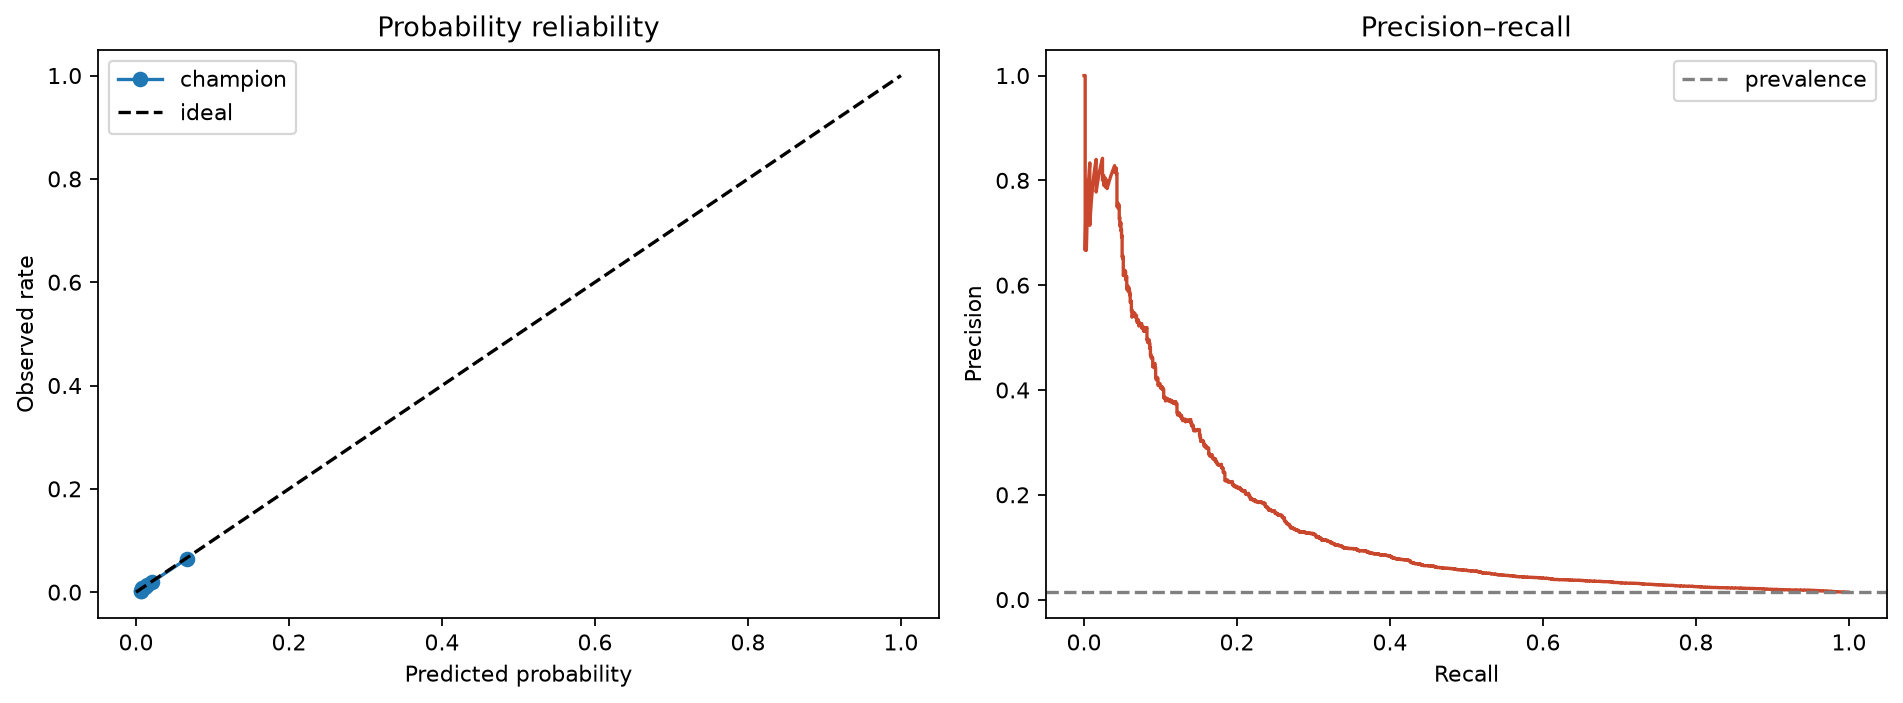

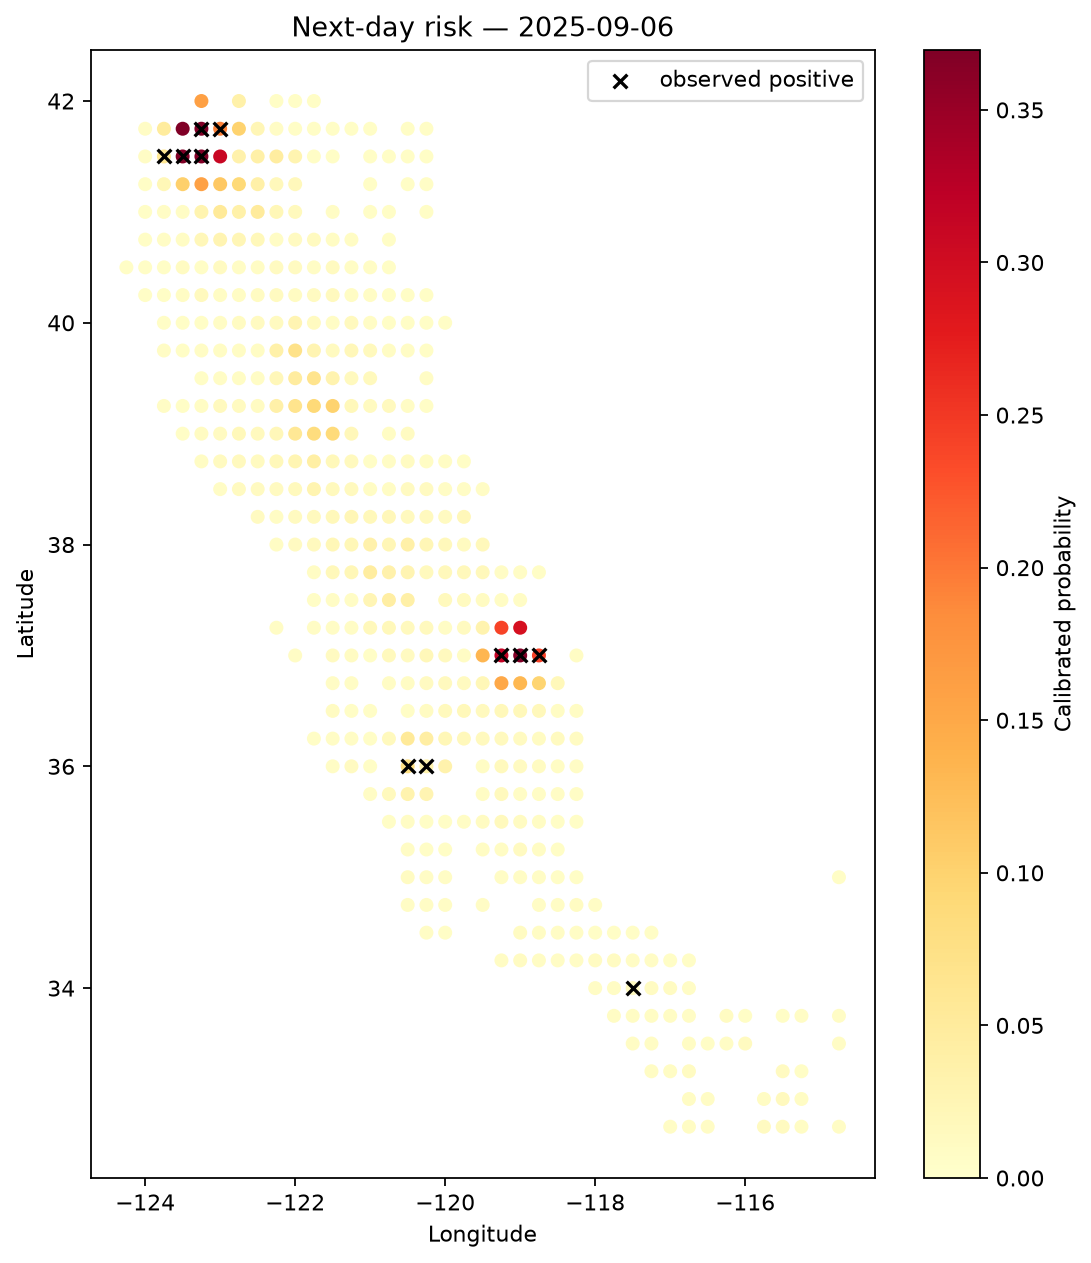

In [150]:
observed, predicted = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
precision, recall, _ = precision_recall_curve(y_test, p_test)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(predicted, observed, marker="o", label="champion")
axes[0].plot([0, 1], [0, 1], "--", color="black", label="ideal")
axes[0].set(title="Probability reliability", xlabel="Predicted probability", ylabel="Observed rate")
axes[0].legend()
axes[1].plot(recall, precision, color="#c9472c")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="prevalence")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
axes[1].legend()
figure.tight_layout()
calibration_plot = plots_dir / "calibration_and_precision_recall.png"
figure.savefig(calibration_plot, dpi=160, bbox_inches="tight")
plt.close(figure)
show_image(calibration_plot)

peak_day = scored.groupby("label_date")["p_fire"].max().idxmax()
day = scored.loc[scored["label_date"].eq(peak_day)]
figure, axis = plt.subplots(figsize=(7, 8))
points = axis.scatter(
    day["longitude"], day["latitude"], c=day["p_fire"], cmap="YlOrRd",
    vmin=0, vmax=max(float(day["p_fire"].quantile(0.99)), 1e-5), s=28,
)
positives = day.loc[day["y_fire"].eq(1)]
if len(positives):
    axis.scatter(positives["longitude"], positives["latitude"], marker="x", color="black", s=38, label="observed positive")
    axis.legend()
axis.set(title=f"Next-day risk — {pd.Timestamp(peak_day).date()}", xlabel="Longitude", ylabel="Latitude")
figure.colorbar(points, ax=axis, label="Calibrated probability")
figure.tight_layout()
risk_map = plots_dir / "peak_day_risk_map.png"
figure.savefig(risk_map, dpi=160, bbox_inches="tight")
plt.close(figure)
show_image(risk_map)


## 10. Classifier explainability

**What the next cell does:** compute LightGBM TreeSHAP contributions on a test sample and plot top feature impacts.


,feature,mean_absolute_contribution,gain_importance
83,fire_distance_weighted_count_7d_lag2,0.255725,921682.461815
82,fire_distance_weighted_count_lag2,0.087521,353527.111351
26,orographic_index,0.079847,33475.432655
20,elevation,0.062158,32915.434082
12,lai_lv_mean,0.044989,12331.323555
48,s5n_s5p_co_mean,0.033395,65974.714169
11,lai_hv_mean,0.031539,19305.005039
84,fire_context_vpd_interaction,0.023138,12801.546188
53,day_of_year_cos,0.022811,11437.089981
65,wind_speed_mean_max_30d,0.021932,8791.779022


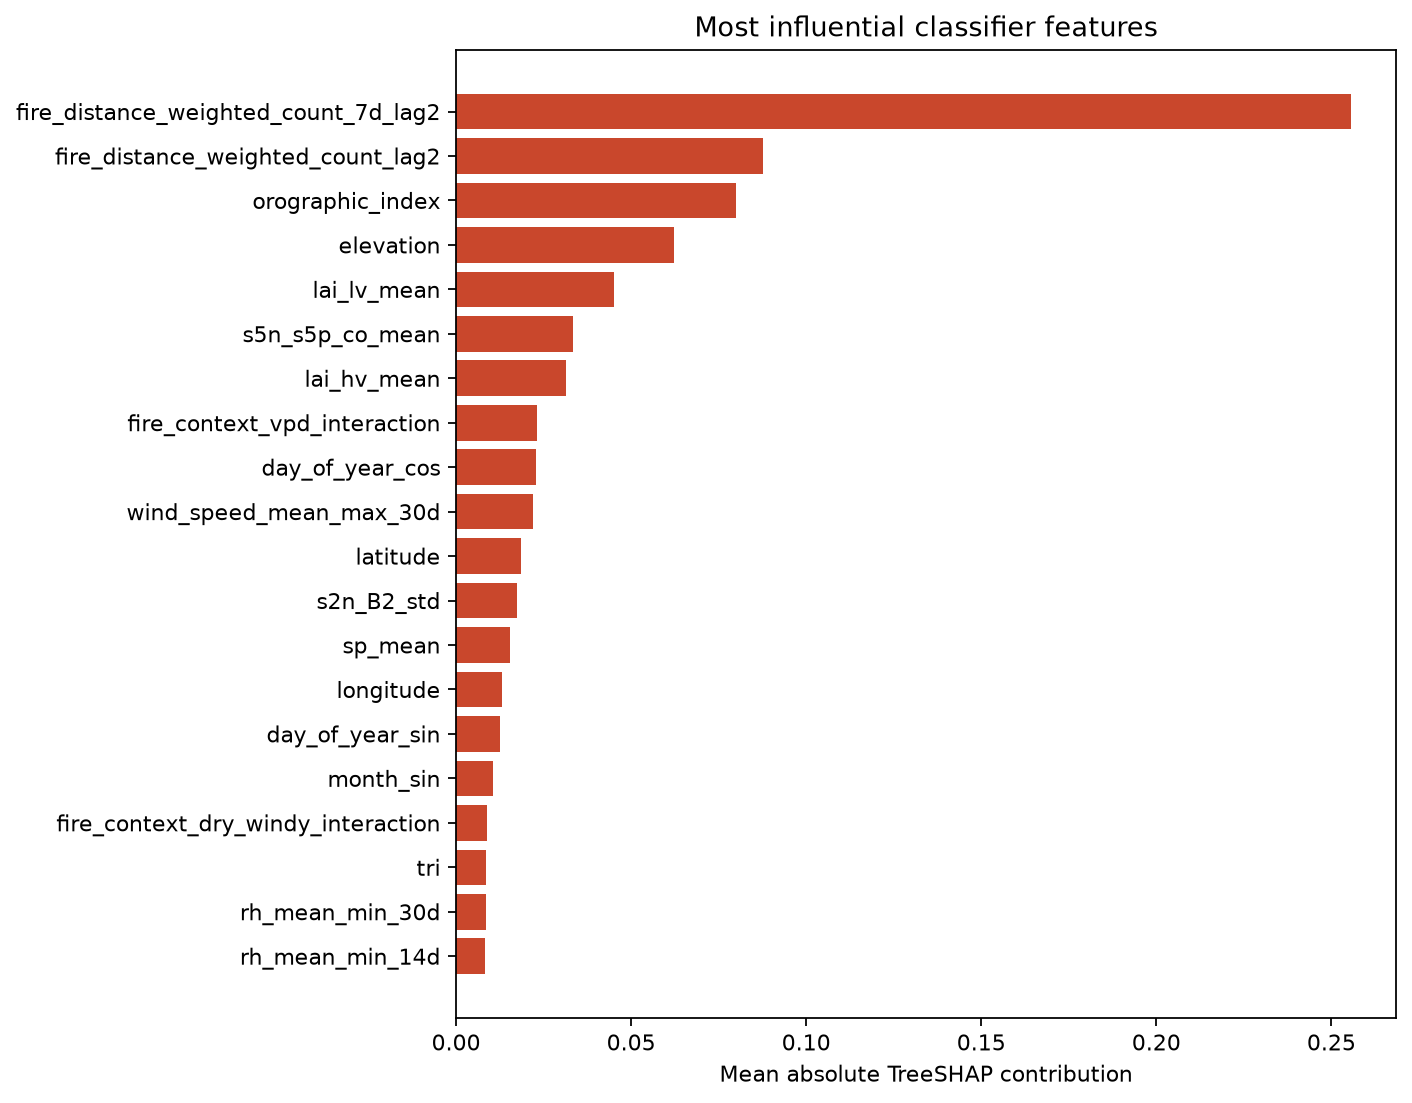

In [151]:
explain_dir = OUTPUT_DIR / "explainability"
explain_dir.mkdir(parents=True, exist_ok=True)
sample = test.sample(min(2000, len(test)), random_state=SEED)
feature_preprocessor = classifier_pipeline.named_steps["feature_preprocessor"]
classifier_model = classifier_pipeline.named_steps["fire_probability_model"]
matrix = feature_preprocessor.transform(sample[feature_columns])
contributions = classifier_model.booster_.predict(matrix, pred_contrib=True)
shap_values = np.asarray(contributions)[:, :-1]
importance = pd.DataFrame({
    "feature": feature_columns,
    "mean_absolute_contribution": np.abs(shap_values).mean(axis=0),
    "gain_importance": classifier_model.booster_.feature_importance(importance_type="gain"),
}).sort_values("mean_absolute_contribution", ascending=False)
importance.to_csv(explain_dir / "feature_explanations.csv", index=False)
show(importance.head(20))

top = importance.head(20).sort_values("mean_absolute_contribution")
figure, axis = plt.subplots(figsize=(9, 7))
axis.barh(top["feature"], top["mean_absolute_contribution"], color="#c9472c")
axis.set(title="Most influential classifier features", xlabel="Mean absolute TreeSHAP contribution")
figure.tight_layout()
importance_plot = explain_dir / "feature_explanations.png"
figure.savefig(importance_plot, dpi=160, bbox_inches="tight")
plt.close(figure)
show_image(importance_plot)

## 11. Export artifact

**What the next cell does:** write `champion_model.joblib`, LightGBM weight files, metrics, feature contract, predictions, and a reload check.



In [152]:
def json_ready(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (Path, pd.Timestamp, datetime)):
        return str(value)
    return value

def write_json(payload: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_ready(payload), indent=2, sort_keys=True) + "\n", encoding="utf-8")

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

models_dir = OUTPUT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "champion_model.joblib"
classifier_weights_path = models_dir / "classifier_weights.txt"
ranker_weights_path = models_dir / "ranker_weights.txt"

model_artifact = {
    "artifact_name": "champion",
    "source_stage": TRAINING_DATA_STAGE,
    "cell_subset": CELL_SUBSET,
    "imputation_method": IMPUTATION_METHOD,
    "use_neighbor_fire_features": bool(globals().get("USE_NEIGHBOR_FIRE_FEATURES", False)),
    "use_fire_season_only": bool(globals().get("USE_FIRE_SEASON_ONLY", False)),
    "fire_season_months": list(globals().get("FIRE_SEASON_MONTHS", ())),
    "missing_flag_column": missing_flag_column,
    "classifier_pipeline": classifier_pipeline,
    "ranker_pipeline": ranker_pipeline,
    "probability_calibrator": probability_calibrator,
    "feature_columns": feature_columns,
    "classifier_params": CLASSIFIER_PARAMS,
    "ranker_params": RANKER_PARAMS,
    "optuna": {
        "enabled": bool(globals().get("ENABLE_OPTUNA", False)),
        "summary": globals().get("optuna_summary"),
    },
    "raw_feature_columns": model_source_features,
    "base_features": base_features,
    "source_columns": load_columns,
    "classifier_weight": float(globals().get("CLASSIFIER_BLEND_WEIGHT", 0.50)),
    "ranker_weight": float(globals().get("RANKER_BLEND_WEIGHT", 0.50)),
    "feature_prune": globals().get("feature_prune_info"),
    "blend_tune": globals().get("blend_tune_info"),
    "data_contract": {
        "label_offset_from_eo_asof_days": 1,
        "eo_asof_offset_from_feature_end_days": 5,
        "expected_grid_cells": int(test["cell_id"].nunique()),
        "archive_source_cells": SOURCE_CELLS,
        "cell_subset": CELL_SUBSET,
        "cell_subset_categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        "selected_cell_ids": SELECTED_TRAINING_CELLS,
        "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
        "archive_last_label_date": str(test["label_date"].max().date()),
        "training_years": [2019, 2020, 2021, 2022],
        "validation_year": 2023,
        "calibration_year": 2024,
        "test_year": 2025,
    },
}
cell_subset_path = models_dir / "selected_cells.json"
write_json({
    "cell_subset": CELL_SUBSET,
    "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
    "n_cells_selected": len(SELECTED_TRAINING_CELLS),
    "cell_ids": SELECTED_TRAINING_CELLS,
    "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
}, cell_subset_path)

joblib.dump(model_artifact, model_path)
classifier_pipeline.named_steps["fire_probability_model"].booster_.save_model(str(classifier_weights_path))
ranker_pipeline.named_steps["daily_priority_model"].booster_.save_model(str(ranker_weights_path))

predictions_path = OUTPUT_DIR / "test_predictions.parquet"
scored.to_parquet(predictions_path, index=False)
feature_contract_path = OUTPUT_DIR / "feature_contract.json"
write_json({
    "source_stage": TRAINING_DATA_STAGE,
    "imputation_method": IMPUTATION_METHOD,
    "use_neighbor_fire_features": bool(globals().get("USE_NEIGHBOR_FIRE_FEATURES", False)),
    "use_fire_season_only": bool(globals().get("USE_FIRE_SEASON_ONLY", False)),
    "fire_season_months": list(globals().get("FIRE_SEASON_MONTHS", ())),
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "feature_groups": feature_groups,
}, feature_contract_path)
metrics_path = OUTPUT_DIR / "metrics.json"
write_json({
    "model": "champion",
    "source_stage": TRAINING_DATA_STAGE,
    "imputation_method": IMPUTATION_METHOD,
    "use_neighbor_fire_features": bool(globals().get("USE_NEIGHBOR_FIRE_FEATURES", False)),
    "use_fire_season_only": bool(globals().get("USE_FIRE_SEASON_ONLY", False)),
    "fire_season_months": list(globals().get("FIRE_SEASON_MONTHS", ())),
    "cell_subset": CELL_SUBSET,
    "cell_subset_info": {
        "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        "n_cells_selected": len(SELECTED_TRAINING_CELLS),
        "n_archive_cells": SOURCE_CELLS,
        "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
    },
    "run_mode": MODE,
    "device": DEVICE,
    "reported_gpu": GPU_NAME,
    "data_quantity": {
        "source_rows": SOURCE_ROWS, "source_cells": SOURCE_CELLS,
        "source_days": SOURCE_DAYS, "source_positives": SOURCE_POSITIVES,
        "splits": split_quantity.to_dict(orient="records"),
    },
    "architecture": {
        "features": len(feature_columns),
        "classifier_pipeline": [IMPUTATION_METHOD, "LightGBM classifier"],
        "ranker_pipeline": [IMPUTATION_METHOD, "LightGBM ranker"],
        "daily_blend": {
            "classifier_percentile": float(globals().get("CLASSIFIER_BLEND_WEIGHT", 0.50)),
            "ranker_percentile": float(globals().get("RANKER_BLEND_WEIGHT", 0.50)),
        },
        "feature_prune": globals().get("feature_prune_info"),
    },
    "validation_2023_descriptive": validation_metrics,
    "test_2025_descriptive": metrics,
}, metrics_path)

# The artifact used by the inference notebook must reproduce both model branches exactly.
loaded = joblib.load(model_path)
verification = test.sort_values(["label_date", "cell_id"]).head(min(1000, len(test)))
original_probability = classifier_pipeline.predict_proba(verification[feature_columns])[:, 1]
loaded_probability = loaded["classifier_pipeline"].predict_proba(verification[feature_columns])[:, 1]
original_rank = ranker_pipeline.predict(verification[feature_columns])
loaded_rank = loaded["ranker_pipeline"].predict(verification[feature_columns])
probability_difference = float(np.max(np.abs(original_probability - loaded_probability)))
rank_difference = float(np.max(np.abs(original_rank - loaded_rank)))
assert probability_difference <= 1e-12
assert rank_difference <= 1e-12

artifacts = [
    model_path, classifier_weights_path, ranker_weights_path, predictions_path,
    feature_contract_path, metrics_path, quantity_plot, calibration_plot, risk_map, importance_plot,
]
manifest_path = OUTPUT_DIR / "run_manifest.json"
write_json({
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model": "champion",
    "source_stage": TRAINING_DATA_STAGE,
    "software": {
        "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__, "lightgbm": lgb.__version__,
    },
    "hardware": {"reported_gpu": GPU_NAME, "lightgbm_device": DEVICE},
    "inputs": {
        "all_parquet": {"path": ALL_PARQUET, "sha256": sha256(ALL_PARQUET)},
        "fire_region_csv": (
            {"path": FIRE_REGION_CSV_PATH, "sha256": sha256(FIRE_REGION_CSV_PATH)}
            if FIRE_REGION_CSV_PATH is not None else None
        ),
        "meta_json": {"path": META_JSON, "sha256": sha256(META_JSON)},
        "dataset_metadata_json": {"path": DATASET_METADATA_JSON, "sha256": sha256(DATASET_METADATA_JSON)},
        "feature_columns_json": {"path": FEATURE_COLUMNS_JSON, "sha256": sha256(FEATURE_COLUMNS_JSON)},
    },
    "artifacts": {
        path.name: {"path": path, "size_bytes": path.stat().st_size, "sha256": sha256(path)}
        for path in artifacts
    },
    "reload_check": {
        "rows": len(verification),
        "maximum_classifier_difference": probability_difference,
        "maximum_ranker_difference": rank_difference,
    },
}, manifest_path)

print("Training outputs for the inference notebook:")
for path in (model_path, classifier_weights_path, ranker_weights_path, feature_contract_path, metrics_path, manifest_path):
    print(f"  {path}")
print(f"Artifact reload passed on {len(verification):,} rows with zero difference.")


Training outputs for the inference notebook:
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/models/champion_model.joblib
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/models/classifier_weights.txt
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/models/ranker_weights.txt
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/feature_contract.json
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/metrics.json
  /Users/Ripunjay.Kumar/Documents/TrainModel-DSAI/notebook_outputs/champion_training_stage_c_knn_high_medium_fire_full/run_manifest.json
Artifact reload passed on 1,000 rows with zero difference.


## 12. Handoff to inference

**What this means:** training is done. Attach this run’s output dataset + matching history pack in the inference notebook. Inference only loads weights — it never `.fit()`.

Sections **13+** are optional diagnostics / sample generation on the fitted LightGBM model.


## 13. Post-training diagnostics & sample generation

**What the next cell does:** define scoring helpers (LightGBM → logit calibrator → tuned blend → Top-25 labels).

**How to read the output:** print of blend weights in use. No metrics yet — helpers only


In [ ]:
# --- 13a. Scoring helpers (LightGBM + logit calibrator + tuned blend) ---
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, classification_report

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("seaborn not installed — heatmaps will use matplotlib only")

DIAG_DIR = OUTPUT_DIR / "diagnostics"
DIAG_DIR.mkdir(parents=True, exist_ok=True)

_clf_w = float(globals().get("CLASSIFIER_BLEND_WEIGHT", 0.50))
_rnk_w = float(globals().get("RANKER_BLEND_WEIGHT", 0.50))
print(f"Using blend weights: classifier={_clf_w:.2f}, ranker={_rnk_w:.2f}")


def score_wildfire_frame(df: pd.DataFrame, top_k: int = 25) -> pd.DataFrame:
    """Calibrated probabilities + ranker + daily blend + Top-K flags + 4-color labels."""
    frame = df.copy()
    frame["label_date"] = pd.to_datetime(frame["label_date"])

    raw_prob = classifier_pipeline.predict_proba(frame[feature_columns])[:, 1]
    clipped = np.clip(raw_prob, 1e-7, 1 - 1e-7)
    logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    frame["p_fire_raw"] = raw_prob.astype("float32")
    frame["p_fire"] = probability_calibrator.predict_proba(logits)[:, 1].astype("float32")

    rank_sorted = frame.sort_values(["label_date", "cell_id"])
    rank_vals = ranker_pipeline.predict(rank_sorted[feature_columns])
    frame["rank_score"] = (
        pd.Series(rank_vals, index=rank_sorted.index).reindex(frame.index).to_numpy(dtype="float32")
    )

    frame["classifier_pct"] = within_day_percentile(frame["p_fire"].to_numpy(), frame["label_date"])
    frame["ranker_pct"] = within_day_percentile(frame["rank_score"].to_numpy(), frame["label_date"])
    frame["alert_score"] = (
        _clf_w * frame["classifier_pct"] + _rnk_w * frame["ranker_pct"]
    ).astype("float32")

    frame["daily_rank"] = frame.groupby("label_date")["alert_score"].rank(
        ascending=False, method="first"
    )
    frame["top_alert"] = (frame["daily_rank"] <= top_k).astype("int8")

    conditions = [
        (frame["y_fire"] == 1) & (frame["top_alert"] == 1),
        (frame["y_fire"] == 0) & (frame["top_alert"] == 1),
        (frame["y_fire"] == 1) & (frame["top_alert"] == 0),
        (frame["y_fire"] == 0) & (frame["top_alert"] == 0),
    ]
    choices = [
        "Blue (HIT)",
        "Red (False Alarm)",
        "Purple (Missed Fire)",
        "Green (Safe)",
    ]
    frame["confusion_category"] = np.select(conditions, choices, default="Green (Safe)")
    return frame


def run_wildfire_inference(
    df: pd.DataFrame, target_date: str | None = None, top_k: int = 25
) -> pd.DataFrame:
    """Score full split or a single label_date; print confusion-category counts."""
    frame = df.copy()
    frame["label_date"] = pd.to_datetime(frame["label_date"])
    if target_date is not None:
        dt = pd.to_datetime(target_date)
        frame = frame.loc[frame["label_date"].eq(dt)].copy()
        if frame.empty:
            raise ValueError(f"No rows for target_date={target_date!r}")
    scored_frame = score_wildfire_frame(frame, top_k=top_k)
    print("=" * 60)
    print(
        f"INFERENCE | dates={scored_frame['label_date'].nunique()} | "
        f"rows={len(scored_frame):,} | cells={scored_frame['cell_id'].nunique()} | top_k={top_k}"
    )
    print(scored_frame["confusion_category"].value_counts().to_string())
    print("=" * 60)
    return scored_frame


print("Scoring helpers ready.")


### 13b. Slice analysis

**What the next cell does:** score 2023 validation and report PR-AUC / Recall@25 on season, wind, VPD, and sensor-freshness slices.

**How to read the output:** compare slices to Overall. Big drops on high-wind or imputed-S2 slices mean the model is weaker in those regimes.


In [ ]:
def evaluate_k_alerts(df: pd.DataFrame, k: int = 25, score_col: str = "alert_score") -> dict:
    alerts = (
        df.sort_values(["label_date", score_col], ascending=[True, False])
        .groupby("label_date", sort=False, group_keys=False)
        .head(k)
    )
    total_positives = int(df["y_fire"].sum())
    true_alerts = int(alerts["y_fire"].sum())
    total_alerts = len(alerts)
    precision = float(true_alerts / total_alerts) if total_alerts else 0.0
    recall = float(true_alerts / total_positives) if total_positives else 0.0
    f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "precision_at_25": precision,
        "recall_at_25": recall,
        "f1_at_25": f1,
        "true_alerts": true_alerts,
        "total_alerts": total_alerts,
    }


def compute_slice_metrics(df: pd.DataFrame, slice_name: str, score_col: str = "alert_score") -> dict:
    positives = int(df["y_fire"].sum())
    rows = len(df)
    if positives == 0 or positives == rows:
        return {
            "slice": slice_name, "rows": rows, "positives": positives,
            "pos_rate": positives / rows if rows else 0.0,
            "pr_auc": np.nan, "roc_auc": np.nan,
            "precision_at_25": np.nan, "recall_at_25": np.nan, "f1_at_25": np.nan,
        }
    prob_col = "p_fire" if "p_fire" in df.columns else score_col
    k_metrics = evaluate_k_alerts(df, k=25, score_col=score_col)
    return {
        "slice": slice_name,
        "rows": rows,
        "positives": positives,
        "pos_rate": float(positives / rows),
        "pr_auc": float(average_precision_score(df["y_fire"], df[prob_col])),
        "roc_auc": float(roc_auc_score(df["y_fire"], df[prob_col])),
        **k_metrics,
    }


def run_subgroup_slice_analysis(eval_df: pd.DataFrame, score_col: str = "alert_score") -> pd.DataFrame:
    df = eval_df.copy()
    df["label_date"] = pd.to_datetime(df["label_date"])
    df["month"] = df["label_date"].dt.month
    rows = []
    rows.append(compute_slice_metrics(df, "1. Overall", score_col))

    peak = df["month"].isin([6, 7, 8, 9, 10])
    rows.append(compute_slice_metrics(df.loc[peak], "2a. Peak season (Jun-Oct)", score_col))
    rows.append(compute_slice_metrics(df.loc[~peak], "2b. Off-season (Nov-May)", score_col))

    if "i10fg_max" in df.columns:
        high_wind = df["i10fg_max"] > 10.0
        rows.append(compute_slice_metrics(df.loc[high_wind], "3a. High wind gust (>10 m/s)", score_col))
        rows.append(compute_slice_metrics(df.loc[~high_wind], "3b. Normal wind gust (<=10)", score_col))
    if "vpd_kpa" in df.columns:
        high_vpd = df["vpd_kpa"] > 2.0
        rows.append(compute_slice_metrics(df.loc[high_vpd], "3c. High VPD (>2.0 kPa)", score_col))

    if "s2n_available" in df.columns:
        rows.append(compute_slice_metrics(df.loc[df["s2n_available"] == 1], "4a. Fresh Sentinel-2", score_col))
    if "s2n_knn_imputed" in df.columns:
        rows.append(compute_slice_metrics(df.loc[df["s2n_knn_imputed"] == 1], "4b. KNN-imputed S2", score_col))
    elif "s2n_available" in df.columns:
        rows.append(compute_slice_metrics(df.loc[df["s2n_available"] == 0], "4b. Missing/stale S2", score_col))

    out = pd.DataFrame(rows)
    display_df = out.copy()
    display_df["pos_rate"] = display_df["pos_rate"].map(lambda x: f"{x:.2%}")
    for col in ("pr_auc", "roc_auc", "f1_at_25"):
        display_df[col] = display_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    for col in ("precision_at_25", "recall_at_25"):
        display_df[col] = display_df[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
    return out, display_df


# Score validation (2023) for slice analysis — uses in-memory engineered features
validation_scored = score_wildfire_frame(validation)
slice_raw, slice_summary = run_subgroup_slice_analysis(validation_scored, score_col="alert_score")
slice_path = DIAG_DIR / "slice_analysis_validation_2023.csv"
slice_raw.to_csv(slice_path, index=False)
print("=" * 80)
print("SUBGROUP & SLICE ANALYSIS (validation 2023)")
print("=" * 80)
show(slice_summary)
print(f"Wrote {slice_path}")


### 13c. Map helper

**What the next cell does:** define the 4-color spatial confusion map (Green TN / Blue HIT / Red false alarm / Purple miss).

**How to read the output:** confirmation that the plot helper is ready. Maps are drawn in the following cell.


In [ ]:
def plot_grid_confusion_map(
    inference_df: pd.DataFrame,
    target_date: str | None = None,
    save_name: str | None = None,
):
    """Spatial map of Top-25 confusion categories for one label_date."""
    frame = inference_df.copy()
    frame["label_date"] = pd.to_datetime(frame["label_date"])
    if target_date is not None:
        dt = pd.to_datetime(target_date)
        frame = frame.loc[frame["label_date"].eq(dt)].copy()
        if frame.empty:
            raise ValueError(f"No inference rows for target_date={target_date!r}")
        date_title = f"Date: {dt.date()}"
    else:
        latest = frame["label_date"].max()
        frame = frame.loc[frame["label_date"].eq(latest)].copy()
        date_title = f"Date: {latest.date()} (latest)"

    n_cells = int(frame["cell_id"].nunique())
    fig, ax = plt.subplots(figsize=(9, 10))

    green = frame.loc[frame["confusion_category"] == "Green (Safe)"]
    red = frame.loc[frame["confusion_category"] == "Red (False Alarm)"]
    purple = frame.loc[frame["confusion_category"] == "Purple (Missed Fire)"]
    blue = frame.loc[frame["confusion_category"] == "Blue (HIT)"]

    ax.scatter(green["longitude"], green["latitude"], c="#2ca02c", s=45, alpha=0.55,
               edgecolors="none", label=f"Green: Safe ({len(green)})")
    if not red.empty:
        ax.scatter(red["longitude"], red["latitude"], c="#d62728", marker="^", s=110,
                   linewidths=1.2, edgecolors="black", label=f"Red: False Alarm ({len(red)})")
    if not purple.empty:
        ax.scatter(purple["longitude"], purple["latitude"], c="#9467bd", marker="s", s=120,
                   linewidths=1.5, edgecolors="black", label=f"Purple: Missed Fire ({len(purple)})")
    if not blue.empty:
        ax.scatter(blue["longitude"], blue["latitude"], c="#1f77b4", marker="*", s=320,
                   linewidths=1.8, edgecolors="black", label=f"Blue: HIT ({len(blue)})")

    ax.set_title(
        f"LightGBM grid confusion map ({n_cells} cells)\n{date_title}\n"
        f"blend clf={_clf_w:.2f} / ranker={_rnk_w:.2f}",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.95, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    fig.tight_layout()

    if save_name is None:
        stamp = str(pd.to_datetime(frame["label_date"].iloc[0]).date())
        save_name = f"grid_confusion_{stamp}.png"
    out = DIAG_DIR / save_name
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)
    show_image(out)
    print(f"Wrote {out}")
    return out


# Alias used by the source notebook
plot_672_grid_confusion_map = plot_grid_confusion_map
print("Map helper ready.")


### 13d. Draw maps (2025 + best 2023 HIT day)

**What the next cell does:** score full 2025 test, map the peak-fire day (and Aug 1/15 if present), and map the validation day with most Blue HITs.

**How to read the output:** Blue stars = caught fires; Purple = misses; Red triangles = false alarms. More Blue and fewer Purple on peak days is better operationally.


In [ ]:
# Full 2025 test inference
test_inference = run_wildfire_inference(test)
test_inf_path = DIAG_DIR / "test_2025_scored_samples.parquet"
test_inference.to_parquet(test_inf_path, index=False)
print(f"Wrote {test_inf_path}")

# Peak fire day in 2025
peak_date = test_inference.groupby("label_date")["y_fire"].sum().idxmax()
peak_date_str = str(pd.Timestamp(peak_date).date())
print(f"Peak fire date in 2025: {peak_date_str}")
plot_grid_confusion_map(test_inference, target_date=peak_date_str, save_name=f"map_peak_{peak_date_str}.png")

# Optional fixed demo dates if present in test
for demo in ("2025-08-15", "2025-08-01"):
    if (test_inference["label_date"] == pd.to_datetime(demo)).any():
        plot_grid_confusion_map(test_inference, target_date=demo, save_name=f"map_{demo}.png")
    else:
        print(f"Skip {demo}: not in scored test set (fire-season filter or missing day)")

# Best HIT day on 2023 validation
val_inference = validation_scored  # already scored in 13b
hits_per_day = (
    val_inference.loc[val_inference["confusion_category"] == "Blue (HIT)"]
    .groupby("label_date")
    .size()
    .sort_values(ascending=False)
)
print("Top 10 validation dates by Blue HITs:")
show(hits_per_day.head(10).rename("blue_hits").to_frame())
if len(hits_per_day):
    top_hit_date = str(pd.Timestamp(hits_per_day.index[0]).date())
    print(f"Plotting best HIT date: {top_hit_date}")
    plot_grid_confusion_map(
        val_inference, target_date=top_hit_date, save_name=f"map_best_hit_val_{top_hit_date}.png"
    )


### 13e. Error categories & FP/FN samples

**What the next cell does:** label TP/FP/FN under `p≥0.5` and Top-25; plot confusion/residuals/spatial errors; export worst FP/FN sample CSVs under `diagnostics/`.

**How to read the output:** Top-25 confusion matters more than `p≥0.5` (alerts are rank-based). Use exported FP/FN CSVs to inspect hard cases (dry/windy false alarms, low-score missed fires).


In [ ]:
# Prefer validation for error mining (chronological holdout used in Optuna / blend)
eval_df = validation_scored.copy()
eval_df["residual"] = eval_df["p_fire"] - eval_df["y_fire"]
eval_df["pred_prob_05"] = (eval_df["p_fire"] >= 0.5).astype("int8")
eval_df["pred_top25"] = (eval_df["daily_rank"] <= 25).astype("int8")


def assign_error_category(y_true: pd.Series, y_pred: pd.Series) -> pd.Series:
    out = np.full(len(y_true), "True Negative (TN)", dtype=object)
    yt = y_true.to_numpy()
    yp = y_pred.to_numpy()
    out[(yt == 1) & (yp == 1)] = "True Positive (TP)"
    out[(yt == 0) & (yp == 1)] = "False Positive (FP - Over-prediction)"
    out[(yt == 1) & (yp == 0)] = "False Negative (FN - Under-prediction)"
    return pd.Series(out, index=y_true.index)


eval_df["cat_prob_05"] = assign_error_category(eval_df["y_fire"], eval_df["pred_prob_05"])
eval_df["cat_top25"] = assign_error_category(eval_df["y_fire"], eval_df["pred_top25"])

print("=== ERROR BREAKDOWN (calibrated p_fire >= 0.5) ===")
print(eval_df["cat_prob_05"].value_counts().to_string())
print("\n=== ERROR BREAKDOWN (daily Top-25 alert) ===")
print(eval_df["cat_top25"].value_counts().to_string())
print("\nclassification_report (Top-25):")
print(classification_report(eval_df["y_fire"], eval_df["pred_top25"], digits=4))

# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cm_prob = confusion_matrix(eval_df["y_fire"], eval_df["pred_prob_05"], labels=[0, 1])
cm_top25 = confusion_matrix(eval_df["y_fire"], eval_df["pred_top25"], labels=[0, 1])

if HAS_SEABORN:
    sns.heatmap(cm_prob, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
                xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
    sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Oranges", ax=axes[0, 1],
                xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
    sns.histplot(data=eval_df, x="residual", hue="y_fire", bins=50, kde=True, ax=axes[1, 0],
                 palette={0: "#1f77b4", 1: "#d62728"})
else:
    for ax, cm, title, cmap in (
        (axes[0, 0], cm_prob, "p >= 0.5", "Blues"),
        (axes[0, 1], cm_top25, "Top-25", "Oranges"),
    ):
        im = ax.imshow(cm, cmap=cmap)
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, str(v), ha="center", va="center")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046)
    axes[1, 0].hist(eval_df.loc[eval_df["y_fire"] == 0, "residual"], bins=50, alpha=0.6, label="y=0")
    axes[1, 0].hist(eval_df.loc[eval_df["y_fire"] == 1, "residual"], bins=50, alpha=0.6, label="y=1")
    axes[1, 0].legend()

axes[0, 0].set_title("Confusion (p_fire >= 0.5)")
axes[0, 0].set_xlabel("Predicted"); axes[0, 0].set_ylabel("True")
axes[0, 1].set_title("Confusion (Top-25 alert)")
axes[0, 1].set_xlabel("Predicted"); axes[0, 1].set_ylabel("True")
axes[1, 0].set_title("Residual (p_fire - y_fire)")
axes[1, 0].set_xlabel("Residual")

eval_df["month"] = pd.to_datetime(eval_df["label_date"]).dt.month
monthly = (
    eval_df.groupby("month")["cat_top25"]
    .apply(lambda s: pd.Series({
        "TP_Hits": int((s == "True Positive (TP)").sum()),
        "FP_Overpredict": int((s == "False Positive (FP - Over-prediction)").sum()),
        "FN_Underpredict": int((s == "False Negative (FN - Under-prediction)").sum()),
    }))
    .unstack()
)
monthly[["TP_Hits", "FP_Overpredict", "FN_Underpredict"]].plot(
    kind="bar", stacked=True, ax=axes[1, 1], color=["#2ca02c", "#ff7f0e", "#d62728"]
)
axes[1, 1].set_title("Monthly Top-25 errors (validation)")
axes[1, 1].set_xlabel("Month"); axes[1, 1].set_ylabel("Count")
fig.tight_layout()
err_plot = DIAG_DIR / "error_diagnostics_validation.png"
fig.savefig(err_plot, dpi=160, bbox_inches="tight")
plt.close(fig)
show_image(err_plot)

# Spatial FP / FN heatmaps
spatial = (
    eval_df.groupby(["cell_id", "latitude", "longitude"], as_index=False)
    .agg(
        total_fps=("cat_top25", lambda s: int((s == "False Positive (FP - Over-prediction)").sum())),
        total_fns=("cat_top25", lambda s: int((s == "False Negative (FN - Under-prediction)").sum())),
        true_fires=("y_fire", "sum"),
    )
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sc1 = ax1.scatter(spatial["longitude"], spatial["latitude"], c=spatial["total_fps"], cmap="YlOrRd", s=40)
plt.colorbar(sc1, ax=ax1, label="FP count")
ax1.set_title("Spatial over-predictions (FP)")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")
sc2 = ax2.scatter(spatial["longitude"], spatial["latitude"], c=spatial["total_fns"], cmap="PuRd", s=40)
plt.colorbar(sc2, ax=ax2, label="FN count")
ax2.set_title("Spatial under-predictions (FN)")
ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude")
fig.tight_layout()
spatial_plot = DIAG_DIR / "spatial_fp_fn_validation.png"
fig.savefig(spatial_plot, dpi=160, bbox_inches="tight")
plt.close(fig)
show_image(spatial_plot)

# --- Sample generation: worst FP / FN for review ---
key_features = [
    c for c in (
        "swvl1_mean", "soil_moisture_index", "vpd_kpa", "wind_speed_mean", "i10fg_max",
        "s2n_NDVI_mean", "s5n_s5p_aai_mean",
        "fire_neighbor_count_7d_lag2", "fire_upwind_count_7d_lag2", "recent_neighbor_fire_context",
    )
    if c in eval_df.columns
]
id_cols = ["label_date", "cell_id", "latitude", "longitude", "y_fire",
           "p_fire", "p_fire_raw", "alert_score", "daily_rank", "confusion_category"]

top_fps = (
    eval_df.loc[eval_df["y_fire"] == 0]
    .sort_values("p_fire", ascending=False)
    .head(50)
)
top_fns = (
    eval_df.loc[eval_df["y_fire"] == 1]
    .sort_values("p_fire", ascending=True)
    .head(50)
)
top25_fps = eval_df.loc[eval_df["cat_top25"] == "False Positive (FP - Over-prediction)"].copy()
top25_fns = eval_df.loc[eval_df["cat_top25"] == "False Negative (FN - Under-prediction)"].copy()

fp_path = DIAG_DIR / "samples_worst_false_positives.csv"
fn_path = DIAG_DIR / "samples_worst_false_negatives.csv"
fp25_path = DIAG_DIR / "samples_top25_false_alarms.csv"
fn25_path = DIAG_DIR / "samples_top25_missed_fires.csv"
eval_path = DIAG_DIR / "validation_2023_scored_with_errors.parquet"

top_fps[id_cols + key_features].to_csv(fp_path, index=False)
top_fns[id_cols + key_features].to_csv(fn_path, index=False)
top25_fps[id_cols + key_features].to_csv(fp25_path, index=False)
top25_fns[id_cols + key_features].to_csv(fn25_path, index=False)
eval_df.to_parquet(eval_path, index=False)

print("\n=== TOP 5 WORST OVER-PREDICTIONS (y=0, high p_fire) ===")
show(top_fps[id_cols + key_features].head(5))
print("\n=== TOP 5 WORST UNDER-PREDICTIONS (y=1, low p_fire) ===")
show(top_fns[id_cols + key_features].head(5))

print("\nSample / diagnostics outputs:")
for p in (fp_path, fn_path, fp25_path, fn25_path, eval_path, slice_path, err_plot, spatial_plot):
    print(f"  {p}")
